# 📊 Exploratory Data Analysis: IT Skills Gap Analysis
## Capstone Project — DBS Foundation x Dicoding

---

## Latar Belakang

Proyek ini membangun sistem AI untuk menganalisis **kesenjangan skill (skills gap)** antara profil kandidat dan kebutuhan pasar kerja IT di Indonesia.  
Data bersumber dari **lowongan kerja LinkedIn** yang telah diekstrak skill-nya menggunakan pipeline NLP berbasis O\*NET + FlashText.

**Dataset yang digunakan:** `JOBS_WITH_EXTRACTED_SKILLS.csv`  
Dataset ini dihasilkan oleh `skill_extraction_pipeline.py` dan menyimpan skill dengan proper casing langsung dari kamus O\*NET.

---

## Pertanyaan Bisnis SMART

| # | Pertanyaan | Kolom Utama | Target Waktu |
|---|---|---|---|
| **BQ1** | Skill IT apa yang **paling banyak diminta** di pasar Indonesia 2022–2026? Adakah pergeseran tren antar tahun? | `hard_skills`, `postedAt` | Analisis historis 4 tahun |
| **BQ2** | Apa **3–5 skill wajib** untuk setiap role IT dengan minimal 50 loker? | `role_label`, `hard_skills` | Per role |
| **BQ3** | Seberapa besar **proporsi loker tanpa skill terdeteksi** per role, dan apa dampaknya pada model? | `role_label`, `hard_skills` | Per role |
| **BQ4** | Seberapa besar **ketimpangan (imbalance)** antar role, dan strategi apa yang tepat sebelum training? | `role_label` | Seluruh dataset |
| **BQ5** | Role IT mana yang **paling kompetitif** berdasarkan rata-rata pelamar per loker? | `role_label`, `applicantsCount` | Per role |
| **BQ6** | Bagaimana **distribusi jenjang karir** antar role, dan skill apa yang membedakan Entry vs Mid-Senior? | `seniorityLevel`, `hard_skills` | Per level |
| **BQ7** | Seberapa besar **adopsi remote work** di IT Indonesia, dan role mana paling remote-friendly? | `workRemoteAllowed`, `role_label` | Per role |

---


## 0. Setup & Import Library

In [24]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ── Warna & tema ─────────────────────────────────────────
C_PRIMARY  = '#2563EB'
C_DANGER   = '#DC2626'
C_SUCCESS  = '#16A34A'
C_WARNING  = '#D97706'
C_LIGHT    = '#94A3B8'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.figsize'    : (12, 6),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# ── Skill noise — diidentifikasi dari audit manual ─────────
# Kata kerja generik / false positive dari kamus O*NET
NOISY_SKILLS = {
    'Analyze', 'Analysis', 'Adapt', 'Develop', 'Development',
    'Create', 'Reduce', 'REDUCE', 'Make', 'Build', 'Design',
    'Support', 'Implement', 'Deploy', 'Monitor', 'Test',
    'Manage', 'Review', 'Ensure', 'Maintain', 'Use',
    'Post', 'POST',
    'Programming languages', 'Programming Language',
    'Deadline', 'deadline',
    'MAGIC', 'Magic',
    'Google',     # terlalu umum; Google Analytics/Sheets/Ads tetap lolos
    'LinkedIn',
    'J', 'xv',    # false positive 1-2 char bukan bahasa pemrograman
}

# Bahasa pemrograman 1-2 karakter yang VALID
VALID_SHORT = {'C', 'Go', 'R', 'C#', 'C++', '.NET'}

def parse_skills(x):
    """Parse kolom extracted_skills dari string-list ke list Python."""
    if pd.isna(x) or x in ('', '[]'):
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

def clean_skills(skills_list):
    """Hapus skill noise; pertahankan proper casing dari FlashText."""
    seen, result = set(), []
    for s in skills_list:
        s = s.strip()
        if not s or s in NOISY_SKILLS:
            continue
        if len(s) == 1 and s not in VALID_SHORT:
            continue
        if s.lower() not in seen:
            seen.add(s.lower())
            result.append(s)
    return result

print('Library siap digunakan.')

Library siap digunakan.


---
## 1. Load & Inspeksi Data Awal

In [25]:
# ─────────────────────────────────────────────────────────
# Gunakan JOBS_WITH_EXTRACTED_SKILLS — hasil FlashText pipeline
# skill disimpan dengan proper casing dari O*NET
# ─────────────────────────────────────────────────────────
RAW_PATH = '../data/processed/JOBS_WITH_EXTRACTED_SKILLS.csv'

df_raw = pd.read_csv(RAW_PATH)

# Parse & bersihkan skill
df_raw['skills_list'] = df_raw['extracted_skills'].apply(parse_skills)
df_raw['skills_list'] = df_raw['skills_list'].apply(clean_skills)
df_raw['skill_count'] = df_raw['skills_list'].apply(len)
df_raw['hard_skills'] = df_raw['skills_list'].apply(lambda l: ', '.join(l))
df_raw['is_no_skill'] = df_raw['skill_count'] == 0

# Parsing tanggal
df_raw['postedAt'] = pd.to_datetime(df_raw['postedAt'], dayfirst=True, errors='coerce')
df_raw['year']     = df_raw['postedAt'].dt.year

print(f'Dataset RAW: {len(df_raw):,} baris x {len(df_raw.columns)} kolom')
print(f'Roles unik : {df_raw["role_label"].nunique()}')
print(f'Kolom      : {df_raw.columns.tolist()}')
df_raw[['role_label', 'hard_skills', 'skill_count']].head(5)

Dataset RAW: 18,768 baris x 26 kolom
Roles unik : 50
Kolom      : ['applicantsCount', 'applyMethod', 'companyName', 'country', 'descriptionText', 'employmentType', 'industries', 'jobFunction', 'location', 'postedAt', 'salary', 'seniorityLevel', 'standardizedTitle', 'title', 'workRemoteAllowed', 'role_label', 'label_score', 'label_source', 'label_keyword', 'translated_descriptionText', 'extracted_skills', 'skill_count', 'skills_list', 'hard_skills', 'is_no_skill', 'year']


,role_label,hard_skills,skill_count
0,Software Engineer,"MongoDB, Spring Boot, Git, Microservices Archi...",5
1,Backend Developer,"Python, Go, Linux",3
2,Frontend Developer,,0
3,Business Analyst,,0
4,Software Engineer,"JavaScript, WordPress, MySQL, Git, HTML, CSS, PHP",7


In [26]:
# Perbandingan skill SEBELUM vs SESUDAH cleaning
all_raw    = []
df_raw['extracted_skills'].apply(parse_skills).apply(lambda l: all_raw.extend(l))
ctr_raw = Counter(all_raw)

all_clean  = []
df_raw['skills_list'].apply(lambda l: all_clean.extend(l))
ctr_clean = Counter(all_clean)

print('=== SEBELUM CLEANING — Top 20 ===')
for s, c in ctr_raw.most_common(20):
    tag = ' <-- NOISE' if s in NOISY_SKILLS else ''
    print(f'  {c:5d}  {s}{tag}')

print()
print('=== SESUDAH CLEANING — Top 20 ===')
for s, c in ctr_clean.most_common(20):
    print(f'  {c:5d}  {s}')

print()
print(f'Total skill unik SEBELUM : {len(ctr_raw)}')
print(f'Total skill unik SESUDAH : {len(ctr_clean)}')
print(f'Skill noise dihapus      : {len(ctr_raw) - len(ctr_clean)}')

=== SEBELUM CLEANING — Top 20 ===
   5932  Python
   3841  React.js
   3633  JavaScript
   3562  Next.js
   2847  TypeScript
   2416  Kubernetes
   2378  Docker
   2378  Analyze <-- NOISE
   2377  Git
   2120  Go
   2076  Node.js
   1591  GitHub
   1579  Google <-- NOISE
   1468  CSS
   1460  HTML
   1446  C#
   1442  Linux
   1407  PostgreSQL
   1402  C
   1306  MySQL

=== SESUDAH CLEANING — Top 20 ===
   5932  Python
   3841  React.js
   3633  JavaScript
   3562  Next.js
   2847  TypeScript
   2416  Kubernetes
   2378  Docker
   2377  Git
   2120  Go
   2076  Node.js
   1591  GitHub
   1468  CSS
   1460  HTML
   1446  C#
   1442  Linux
   1407  PostgreSQL
   1402  C
   1306  MySQL
   1286  NoSQL
   1228  R

Total skill unik SEBELUM : 528
Total skill unik SESUDAH : 520
Skill noise dihapus      : 8


---
## 2. BQ3 — Analisis Missing Skills (Loker Tanpa Skill Terdeteksi)

===== BQ3: Proporsi Loker Tanpa Skill per Role =====
Total loker           : 18,768
Loker tanpa skill     : 3,702 (19.73%)



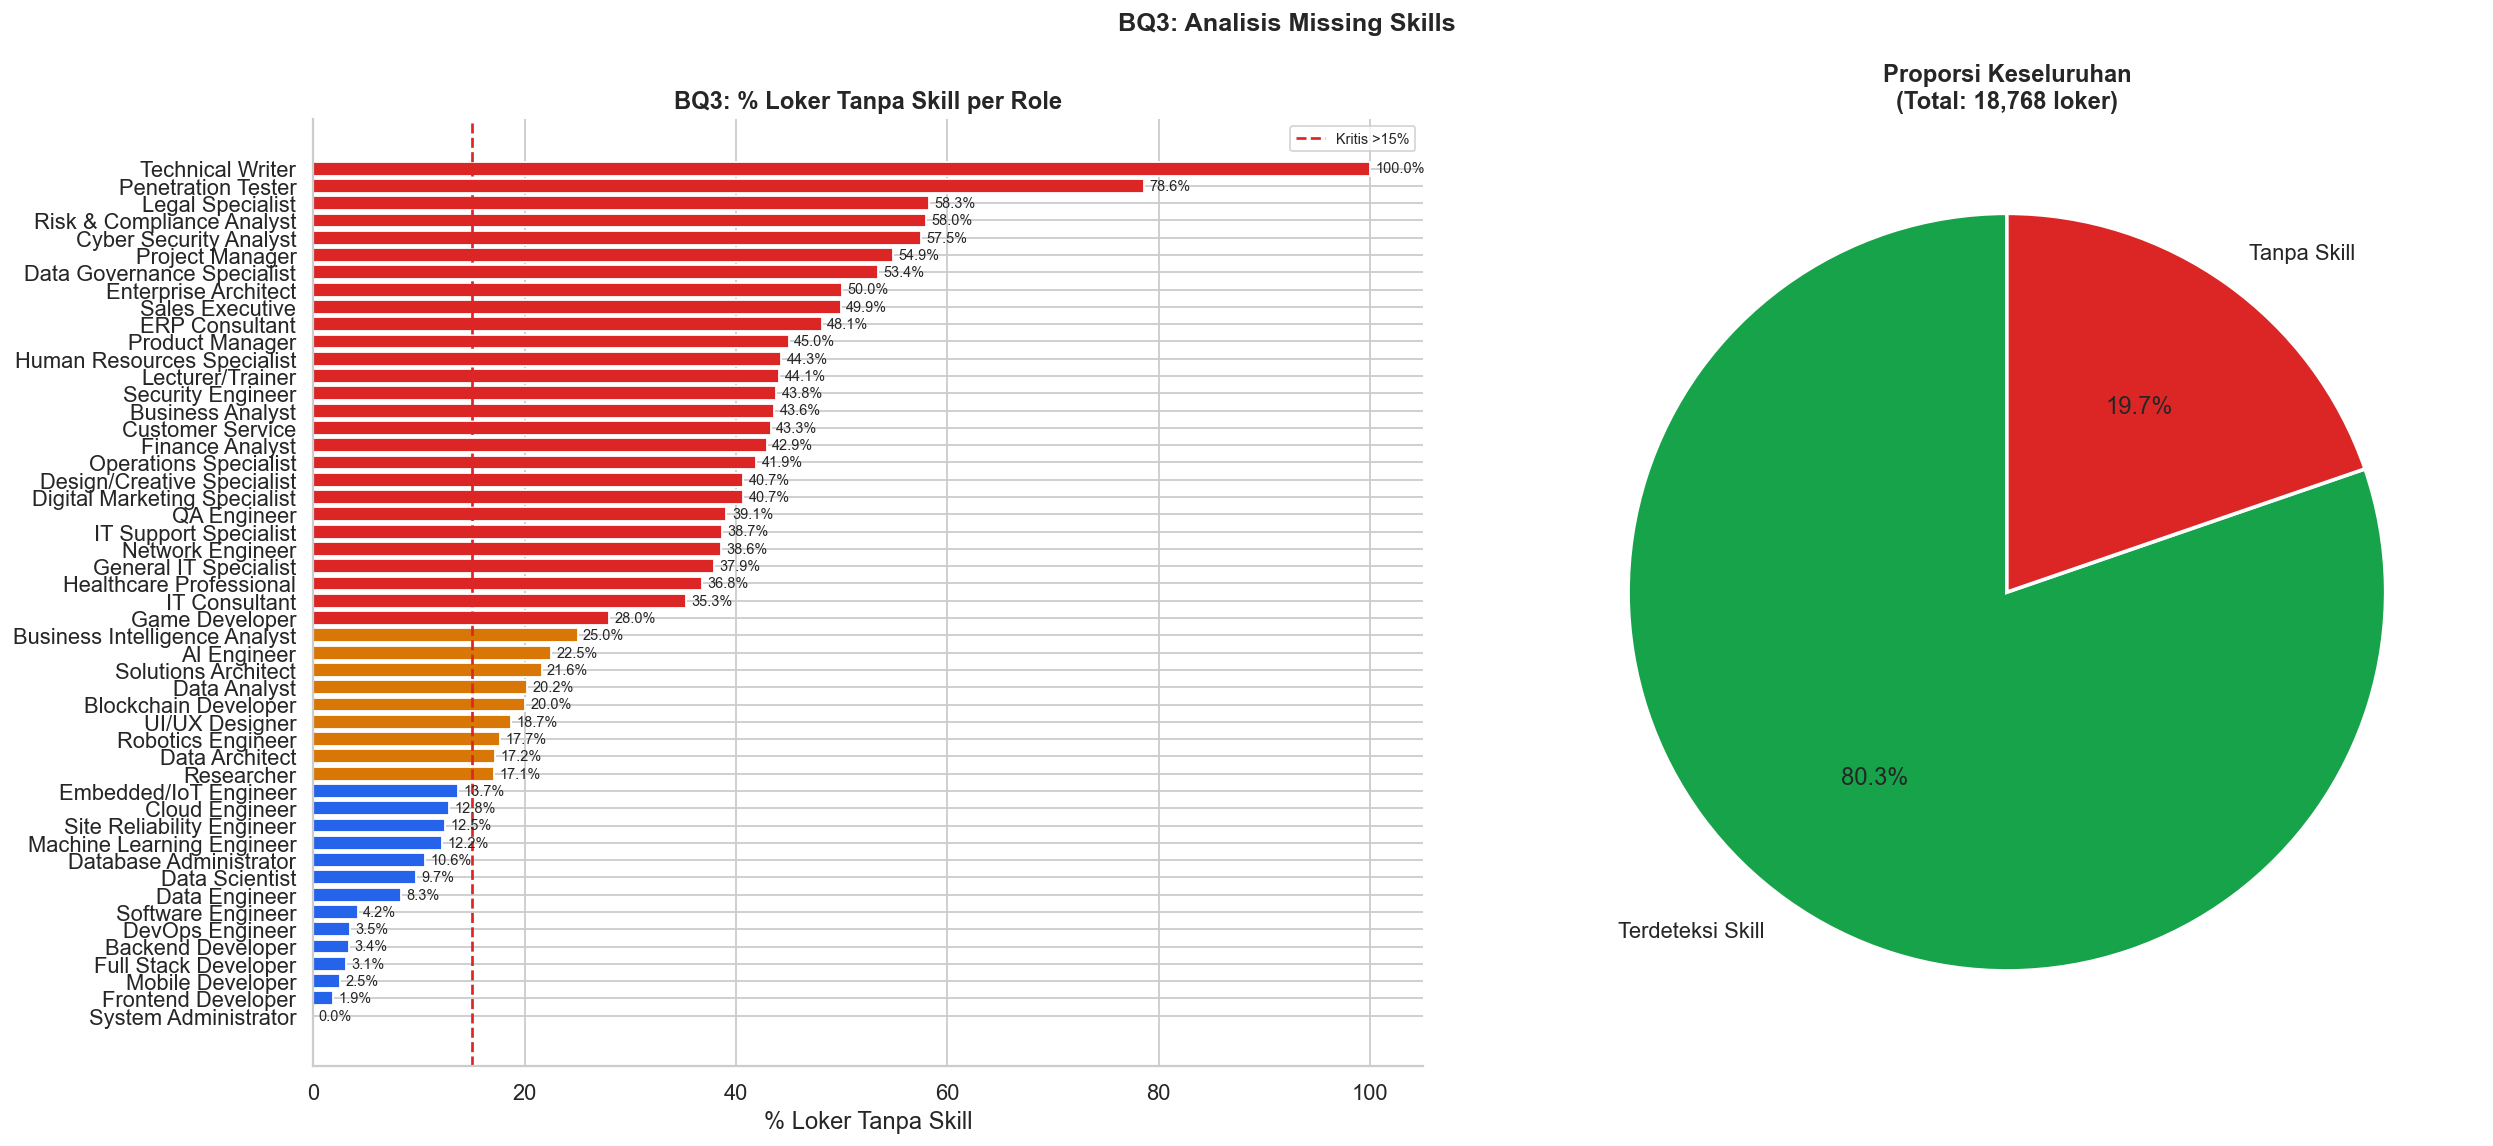


--- 10 Role dengan % Missing Tertinggi ---
                            total  missing    pct
role_label                                       
Technical Writer                1        1  100.0
Penetration Tester             14       11   78.6
Legal Specialist               24       14   58.3
Risk & Compliance Analyst     238      138   58.0
Cyber Security Analyst        127       73   57.5
Project Manager                82       45   54.9
Data Governance Specialist     73       39   53.4
Enterprise Architect           10        5   50.0
Sales Executive               609      304   49.9
ERP Consultant                106       51   48.1


In [27]:
print('===== BQ3: Proporsi Loker Tanpa Skill per Role =====')

missing_by_role = df_raw.groupby('role_label').agg(
    total   = ('is_no_skill', 'count'),
    missing = ('is_no_skill', 'sum'),
).assign(pct=lambda x: (x['missing'] / x['total'] * 100).round(1))
missing_by_role = missing_by_role.sort_values('pct', ascending=False)

# Ringkasan
print(f'Total loker           : {len(df_raw):,}')
print(f'Loker tanpa skill     : {df_raw["is_no_skill"].sum():,} ({df_raw["is_no_skill"].mean()*100:.2f}%)')
print()

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

ax1 = axes[0]
colors = [C_DANGER if v > 25 else C_WARNING if v > 15 else C_PRIMARY
          for v in missing_by_role['pct']]
bars = ax1.barh(missing_by_role.index[::-1], missing_by_role['pct'][::-1], color=colors[::-1])
ax1.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax1.axvline(15, color=C_DANGER, linestyle='--', linewidth=1.5, label='Kritis >15%')
ax1.set_xlabel('% Loker Tanpa Skill')
ax1.set_title('BQ3: % Loker Tanpa Skill per Role', fontweight='bold')
ax1.legend(fontsize=8)

ax2 = axes[1]
pie_labels = ['Terdeteksi Skill', 'Tanpa Skill']
pie_vals   = [len(df_raw) - df_raw['is_no_skill'].sum(), df_raw['is_no_skill'].sum()]
ax2.pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
        colors=[C_SUCCESS, C_DANGER], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title(f'Proporsi Keseluruhan\n(Total: {len(df_raw):,} loker)', fontweight='bold')

fig.suptitle('BQ3: Analisis Missing Skills', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- 10 Role dengan % Missing Tertinggi ---')
print(missing_by_role.head(10).to_string())

In [28]:
# Strategi penanganan missing
print('=== Strategi Penanganan Missing Skills ===')
print()
opsi_a = df_raw[~df_raw['is_no_skill']]  # Drop loker tanpa skill
opsi_b = df_raw.copy()                   # Pertahankan semua
opsi_b.loc[opsi_b['is_no_skill'], 'hard_skills'] = 'no_skills'

print(f'Opsi A — Drop loker tanpa skill (dipakai untuk modeling):')
print(f'  Sebelum : {len(df_raw):,} baris')
print(f'  Sesudah : {len(opsi_a):,} baris')
print(f'  Dibuang : {len(df_raw) - len(opsi_a):,} ({(len(df_raw)-len(opsi_a))/len(df_raw)*100:.1f}%)')
print()
print(f'Opsi B — Imputasi "no_skills" (fallback):')
print(f'  Semua   : {len(opsi_b):,} baris dipertahankan')
print()
print('Keputusan: Opsi A digunakan — kualitas ekstraksi lebih penting untuk model.')

=== Strategi Penanganan Missing Skills ===

Opsi A — Drop loker tanpa skill (dipakai untuk modeling):
  Sebelum : 18,768 baris
  Sesudah : 15,066 baris
  Dibuang : 3,702 (19.7%)

Opsi B — Imputasi "no_skills" (fallback):
  Semua   : 18,768 baris dipertahankan

Keputusan: Opsi A digunakan — kualitas ekstraksi lebih penting untuk model.


---
## 3. BQ4 — Distribusi Role & Penanganan Imbalance

===== BQ4: Distribusi 50 Role (Sebelum Cleaning) =====


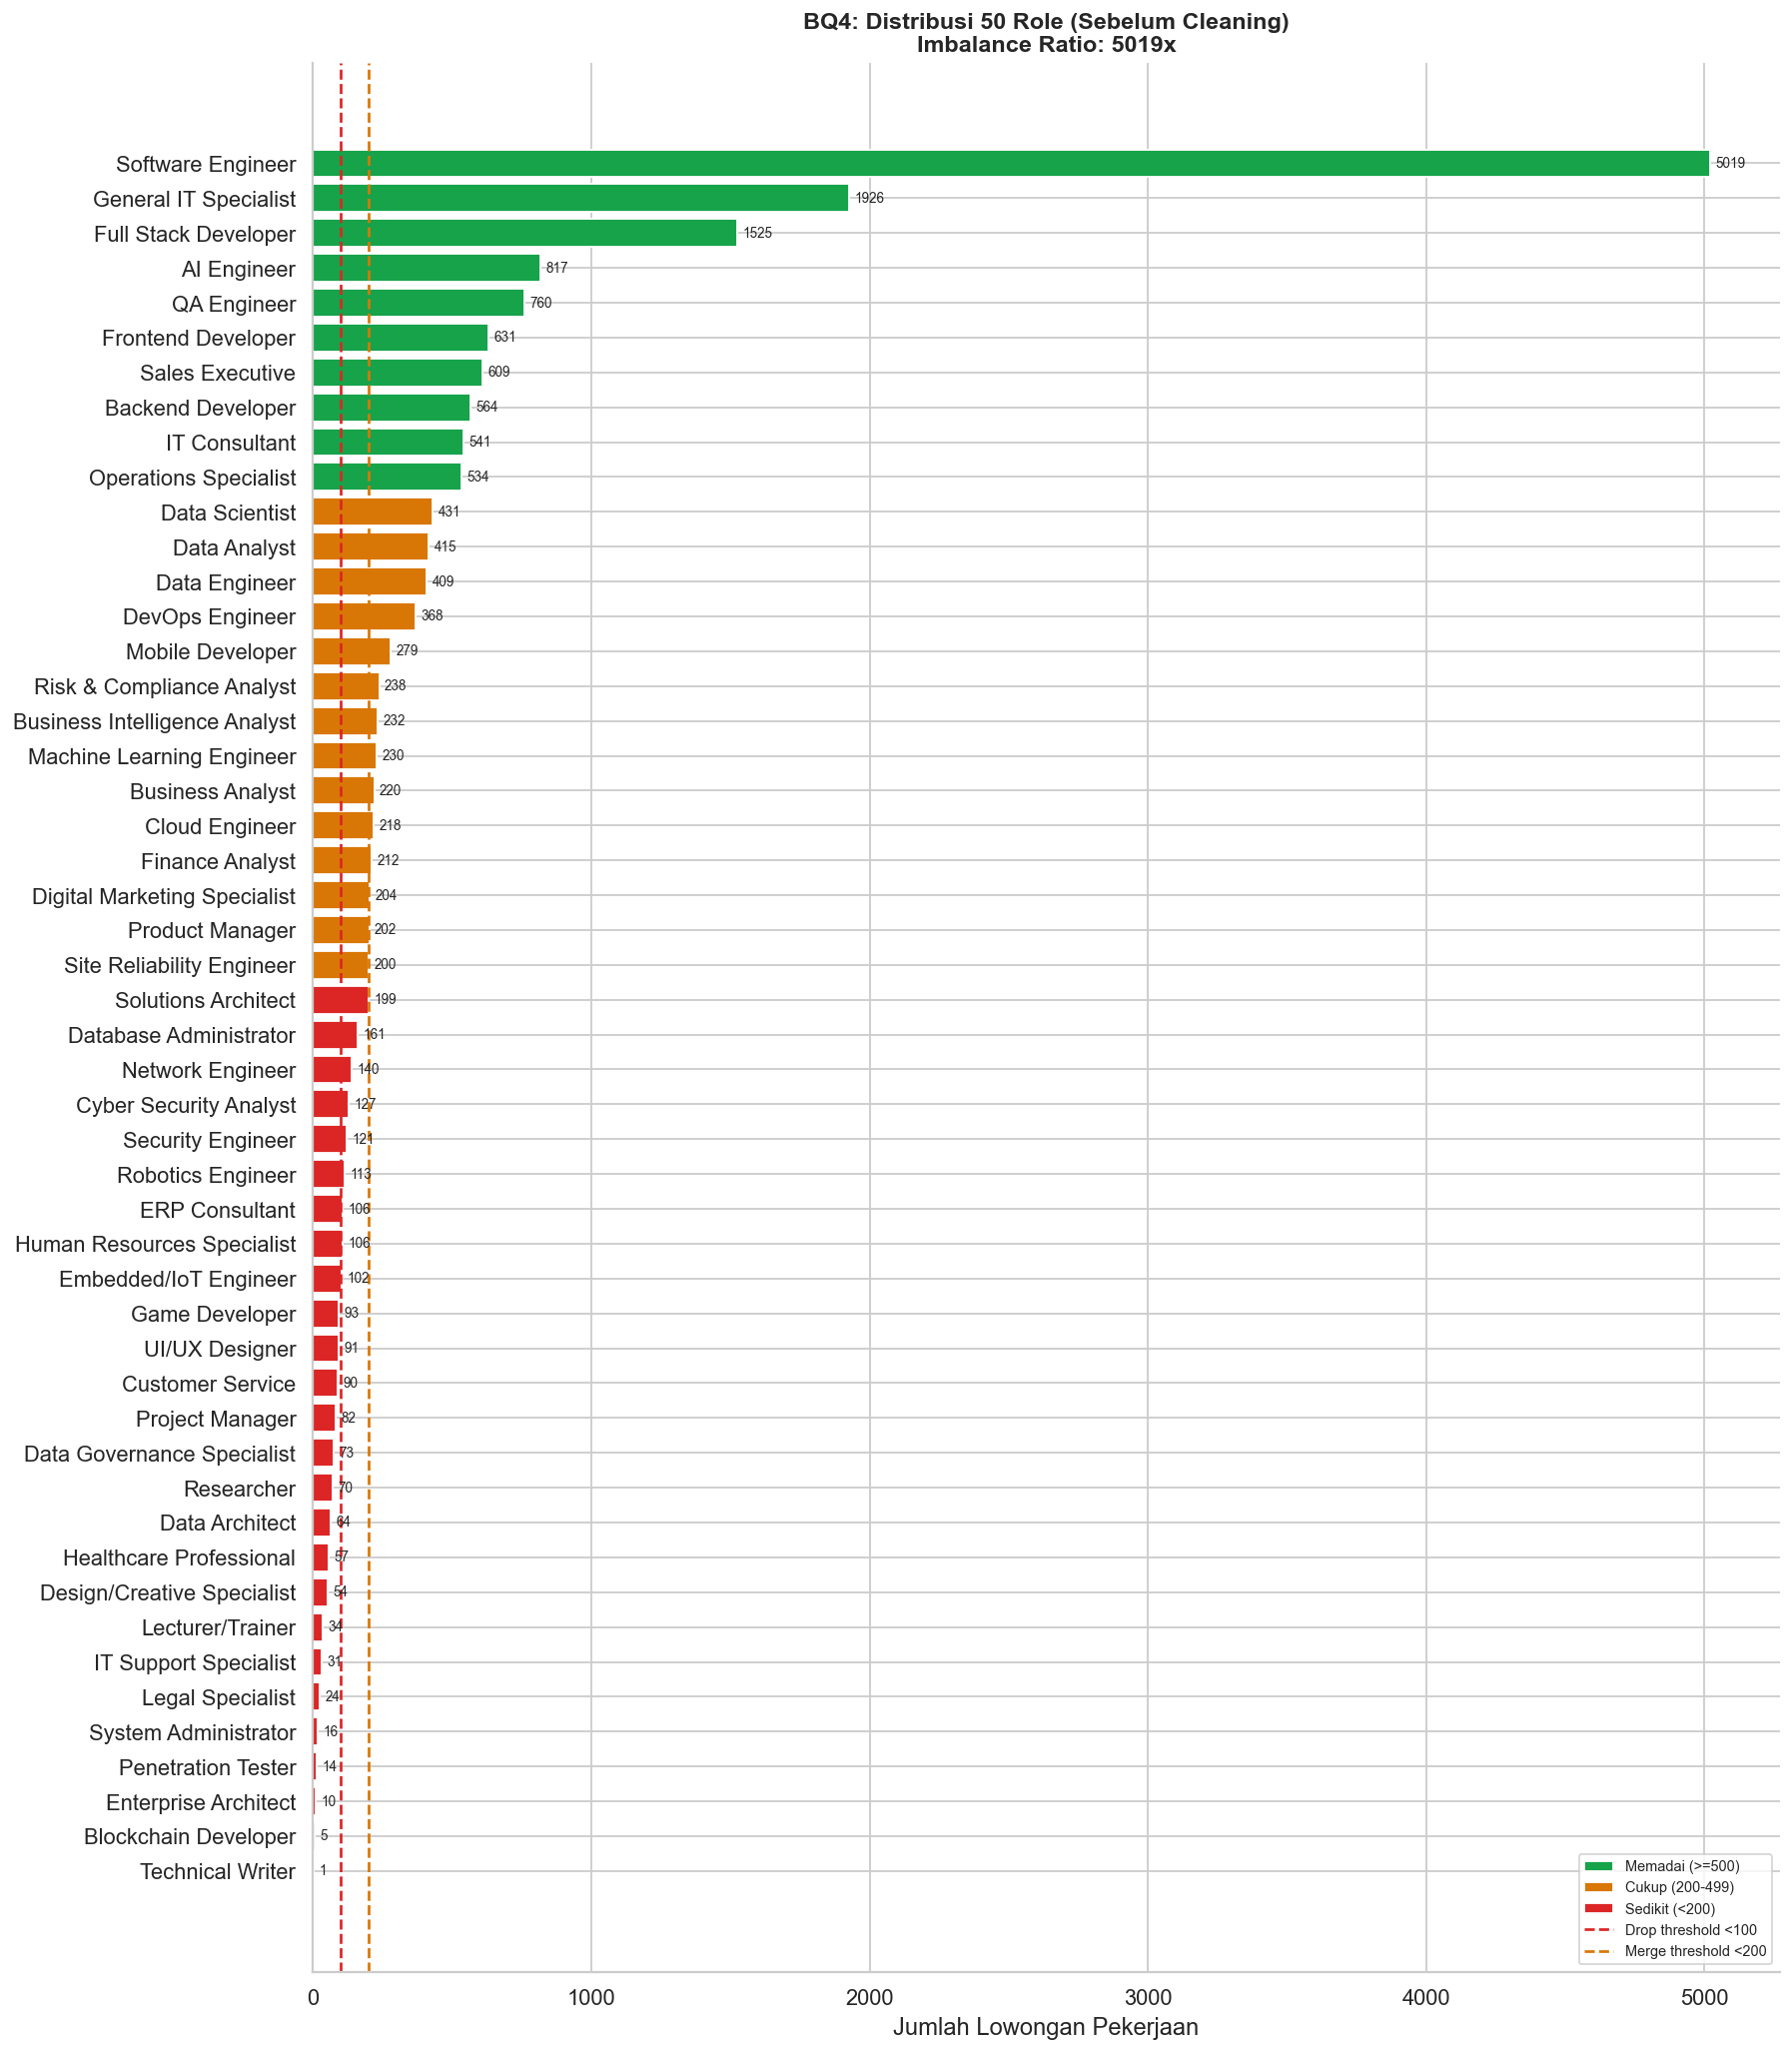

Imbalance ratio: 5019x  (Software Engineer vs Technical Writer)
Role < 100 loker: 17 role
Role non-IT yang diidentifikasi: 13 role


In [29]:
print('===== BQ4: Distribusi 50 Role (Sebelum Cleaning) =====')

rc_raw = df_raw['role_label'].value_counts()

fig, ax = plt.subplots(figsize=(14, 16))
colors_rc = [C_SUCCESS if v >= 500 else C_WARNING if v >= 200 else C_DANGER
             for v in rc_raw.values[::-1]]
bars = ax.barh(rc_raw.index[::-1], rc_raw.values[::-1], color=colors_rc)
ax.bar_label(bars, padding=3, fontsize=7.5)
ax.axvline(100, color=C_DANGER, linestyle='--', linewidth=1.5, label='Threshold drop (<100)')
ax.axvline(200, color=C_WARNING, linestyle='--', linewidth=1.5, label='Threshold merge (<200)')

from matplotlib.patches import Patch
legend_el = [
    Patch(facecolor=C_SUCCESS, label='Memadai (>=500)'),
    Patch(facecolor=C_WARNING, label='Cukup (200-499)'),
    Patch(facecolor=C_DANGER,  label='Sedikit (<200)'),
    plt.Line2D([0],[0], color=C_DANGER,  linestyle='--', label='Drop threshold <100'),
    plt.Line2D([0],[0], color=C_WARNING, linestyle='--', label='Merge threshold <200'),
]
ax.legend(handles=legend_el, loc='lower right', fontsize=8)
ax.set_xlabel('Jumlah Lowongan Pekerjaan')
ax.set_title(f'BQ4: Distribusi 50 Role (Sebelum Cleaning)\nImbalance Ratio: {rc_raw.max()/rc_raw.min():.0f}x',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {rc_raw.max()/rc_raw.min():.0f}x  ({rc_raw.idxmax()} vs {rc_raw.idxmin()})')
print(f'Role < 100 loker: {(rc_raw < 100).sum()} role')
print(f'Role non-IT yang diidentifikasi: 13 role')

In [30]:
# ── Terapkan pipeline cleaning (sama dengan clean_roles.py) ──────────
NON_IT_ROLES = {
    'Sales Executive', 'Operations Specialist', 'Digital Marketing Specialist',
    'Risk & Compliance Analyst', 'Finance Analyst', 'Human Resources Specialist',
    'Customer Service', 'Researcher', 'Healthcare Professional',
    'Design/Creative Specialist', 'Lecturer/Trainer', 'Legal Specialist',
    'Technical Writer',
}

ROLE_MERGE_MAP = {
    'Game Developer'            : 'Software Engineer',
    'UI/UX Designer'            : 'Frontend Developer',
    'Project Manager'           : 'Product Manager',
    'Data Governance Specialist': 'Data Engineer',
    'Data Architect'            : 'Data Engineer',
    'IT Support Specialist'     : 'General IT Specialist',
    'System Administrator'      : 'General IT Specialist',
    'Penetration Tester'        : 'Cyber Security Analyst',
    'Enterprise Architect'      : 'Solutions Architect',
    'Blockchain Developer'      : 'Software Engineer',
    'Cybersecurity Engineer'    : 'Security Engineer',
    'Product/Project Manager'   : 'Product Manager',
}

# 1. Drop Non-IT
df = df_raw[~df_raw['role_label'].isin(NON_IT_ROLES)].copy()
print(f'Setelah drop Non-IT : {len(df):,} baris, {df["role_label"].nunique()} roles')

# 2. Merge roles
df['role_label'] = df['role_label'].replace(ROLE_MERGE_MAP)
print(f'Setelah merge roles : {df["role_label"].nunique()} roles unik')

# 3. Drop loker tanpa skill
df = df[df['skill_count'] > 0].copy()
print(f'Setelah drop missing: {len(df):,} baris')

print('\nDataset df (cleaned) siap untuk analisis EDA lanjutan.')

Setelah drop Non-IT : 16,535 baris, 37 roles
Setelah merge roles : 27 roles unik
Setelah drop missing: 13,844 baris

Dataset df (cleaned) siap untuk analisis EDA lanjutan.


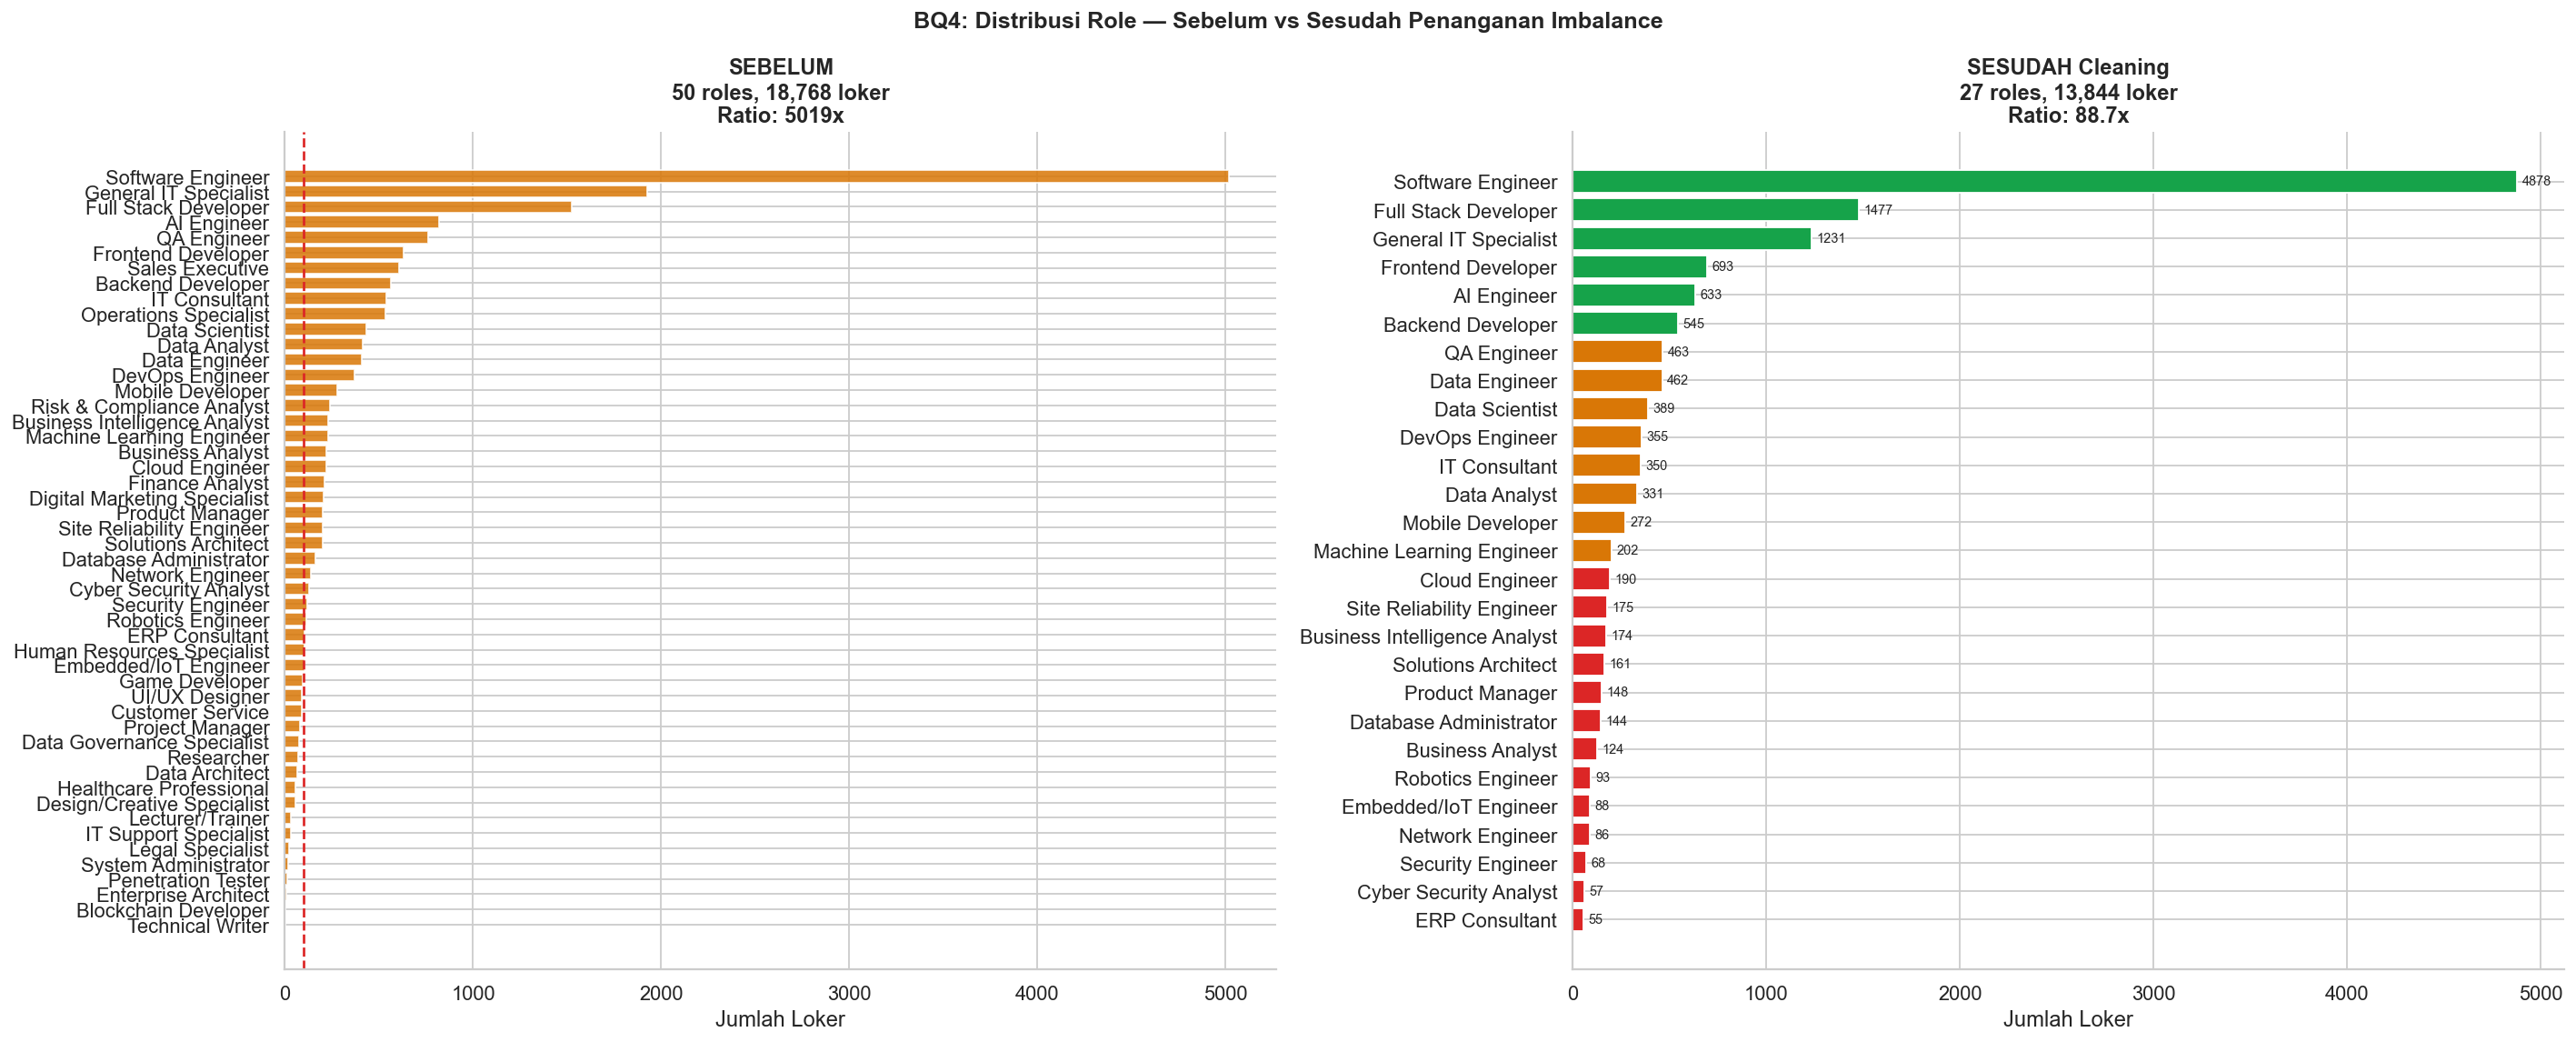

Imbalance ratio: 5019x -> 88.7x
Role di bawah 100 loker: 6 (perlu diperhatikan saat training)


In [31]:
# ── Perbandingan distribusi: Sebelum vs Sesudah ───────────────────────
rc_after = df['role_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# SEBELUM
ax1 = axes[0]
ax1.barh(rc_raw.index[::-1], rc_raw.values[::-1], color=C_WARNING, alpha=0.85)
ax1.axvline(100, color=C_DANGER, linestyle='--', linewidth=1.5)
ax1.set_title(f'SEBELUM\n50 roles, {len(df_raw):,} loker\nRatio: {rc_raw.max()/rc_raw.min():.0f}x', fontweight='bold')
ax1.set_xlabel('Jumlah Loker')

# SESUDAH
ax2 = axes[1]
colors_after = [C_SUCCESS if v >= 500 else C_WARNING if v >= 200 else C_DANGER
                for v in rc_after.values[::-1]]
bars2 = ax2.barh(rc_after.index[::-1], rc_after.values[::-1], color=colors_after)
ax2.bar_label(bars2, padding=3, fontsize=8)
ax2.set_title(f'SESUDAH Cleaning\n{df["role_label"].nunique()} roles, {len(df):,} loker\nRatio: {rc_after.max()/rc_after.min():.1f}x', fontweight='bold')
ax2.set_xlabel('Jumlah Loker')

fig.suptitle('BQ4: Distribusi Role — Sebelum vs Sesudah Penanganan Imbalance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {rc_raw.max()/rc_raw.min():.0f}x -> {rc_after.max()/rc_after.min():.1f}x')
print(f'Role di bawah 100 loker: {(rc_after < 100).sum()} (perlu diperhatikan saat training)')

In [32]:
# ── Analisis role yang masih kecil setelah merge ──────────────────────
print('=== Role dengan loker < 100 setelah cleaning ===')
small_roles = rc_after[rc_after < 100]
print(small_roles.to_string())
print()
print('Opsi tambahan untuk role ini:')
print('  1. Merge ke Software Engineer (jika skill overlap tinggi)')
print('  2. Pertahankan + class_weight="balanced" saat training')
print('  3. Drop jika evaluasi model menunjukkan recall buruk')
print()
print('Rekomendasi: Pertahankan dulu, evaluasi recall per class setelah training.')

=== Role dengan loker < 100 setelah cleaning ===
role_label
Robotics Engineer         93
Embedded/IoT Engineer     88
Network Engineer          86
Security Engineer         68
Cyber Security Analyst    57
ERP Consultant            55

Opsi tambahan untuk role ini:
  1. Merge ke Software Engineer (jika skill overlap tinggi)
  2. Pertahankan + class_weight="balanced" saat training
  3. Drop jika evaluasi model menunjukkan recall buruk

Rekomendasi: Pertahankan dulu, evaluasi recall per class setelah training.


---
## 4. BQ1 — Skill Paling Diminati & Tren Waktu

===== BQ1: Top Skill Paling Diminati Pasar IT Indonesia =====


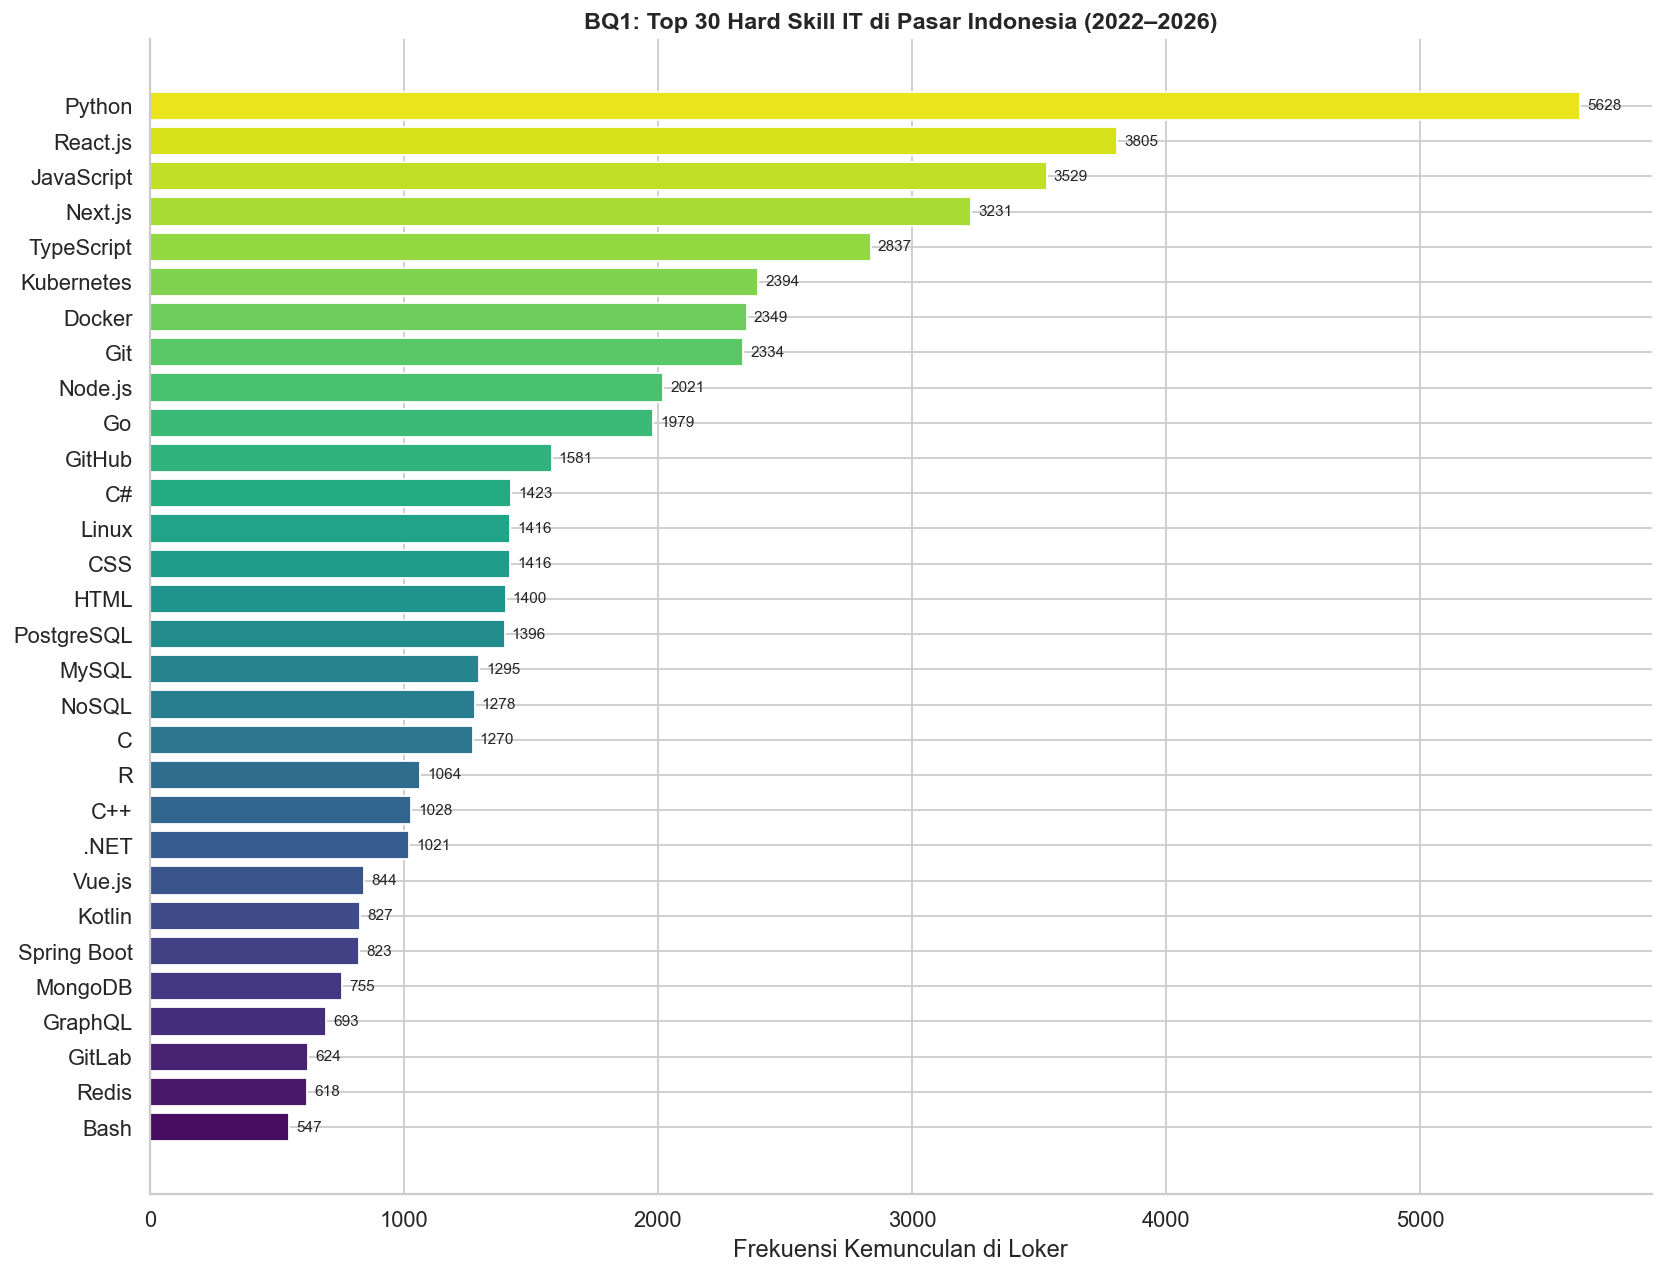

Total skill unik (bersih) : 494
Skill #1: Python — muncul di 5,628 loker


In [ ]:
print('===== BQ1: Top Skill Paling Diminati Pasar IT =====')

all_skills = []
df['skills_list'].apply(lambda l: all_skills.extend(l))
skill_ctr = Counter(all_skills)

top30 = pd.DataFrame(skill_ctr.most_common(30), columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(13, 10))
palette = sns.color_palette('viridis', 30)
bars = ax.barh(top30['skill'][::-1], top30['count'][::-1], color=palette)
ax.bar_label(bars, padding=4, fontsize=8.5)
ax.set_xlabel('Frekuensi Kemunculan di Loker')
ax.set_title('BQ1: Top 30 Hard Skill IT di Pasar Indonesia (2022–2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total skill unik (bersih) : {len(skill_ctr)}')
print(f'Skill #1: {top30.iloc[0]["skill"]} — muncul di {top30.iloc[0]["count"]:,} loker')

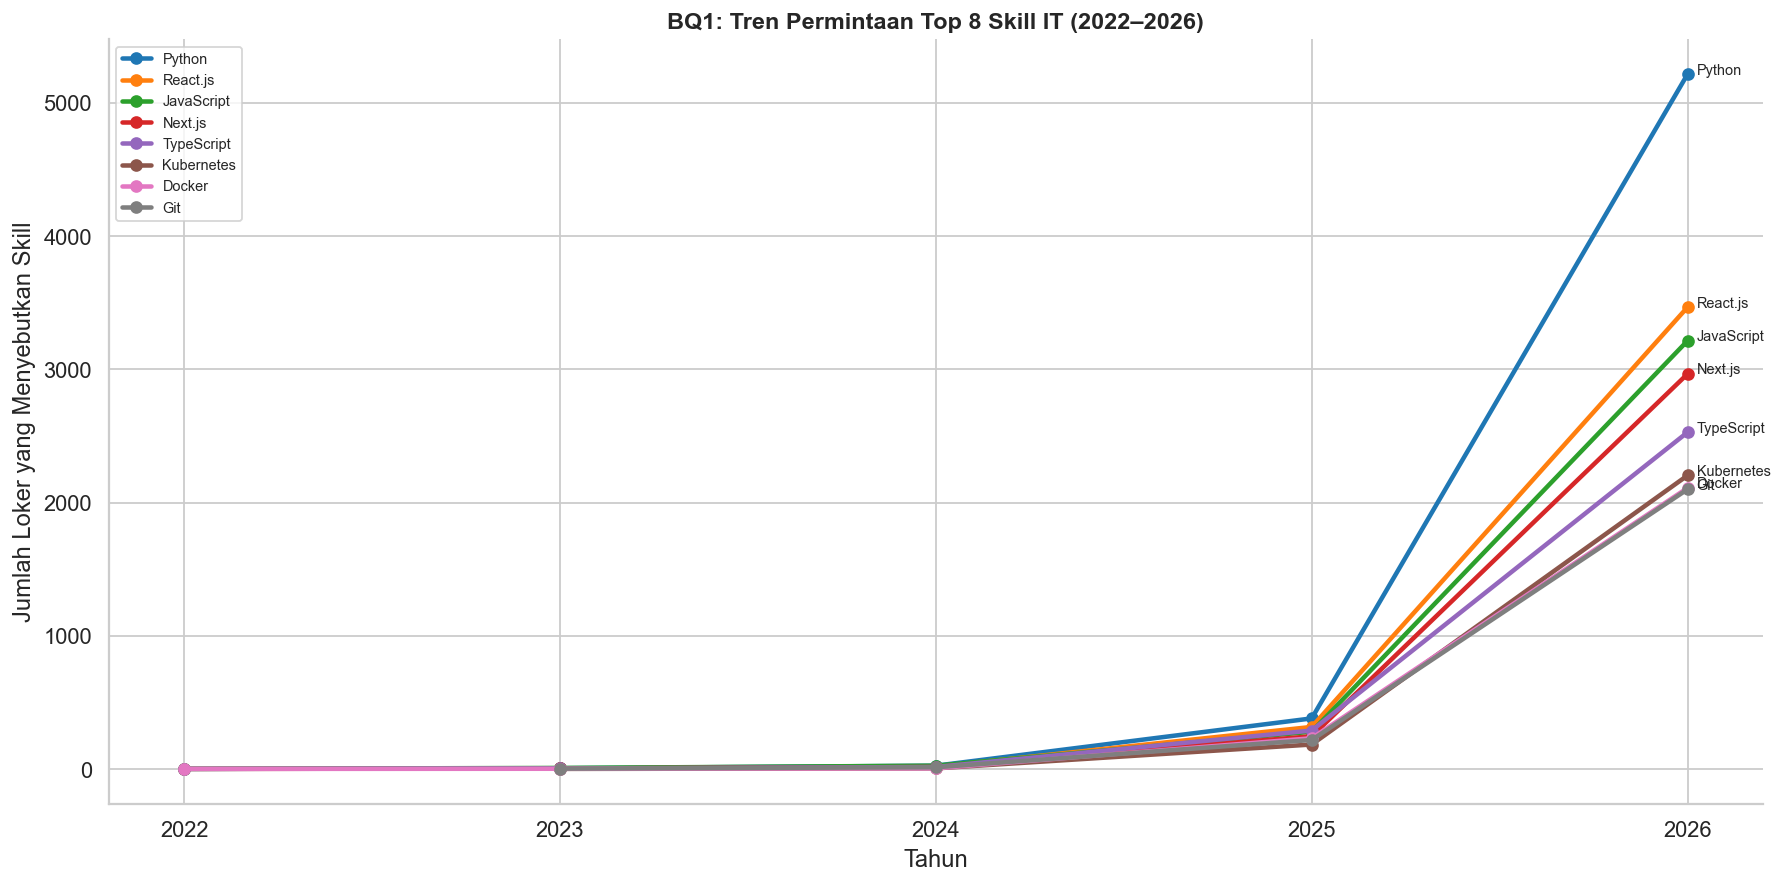

In [45]:
# ── Tren skill top 8 per tahun ────────────────────────────────────────
top8_skills = [s for s, c in skill_ctr.most_common(8)]

ts_rows = []
for _, row in df.dropna(subset=['year']).iterrows():
    yr = int(row['year'])
    if not (2022 <= yr <= 2026):
        continue
    for sk in row['skills_list']:
        if sk in top8_skills:
            ts_rows.append({'Year': yr, 'Skill': sk})

ts_df = pd.DataFrame(ts_rows)
ts_grp = ts_df.groupby(['Year', 'Skill']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(14, 7))
palette_ts = sns.color_palette('tab10', 8)
for i, sk in enumerate(top8_skills):
    d = ts_grp[ts_grp['Skill'] == sk]
    if d.empty:
        continue
    ax.plot(d['Year'], d['Count'], marker='o', linewidth=2.5,
            label=sk, color=palette_ts[i])
    ax.annotate(sk, (d['Year'].iloc[-1], d['Count'].iloc[-1]),
                fontsize=8, ha='left', xytext=(5, 0), textcoords='offset points')

ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Loker yang Menyebutkan Skill')
ax.set_title('BQ1: Tren Permintaan Top 8 Skill IT (2022–2026)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## 5. BQ2 — Skill Wajib per Role IT

===== BQ2: Top Skills Wajib per Role IT =====


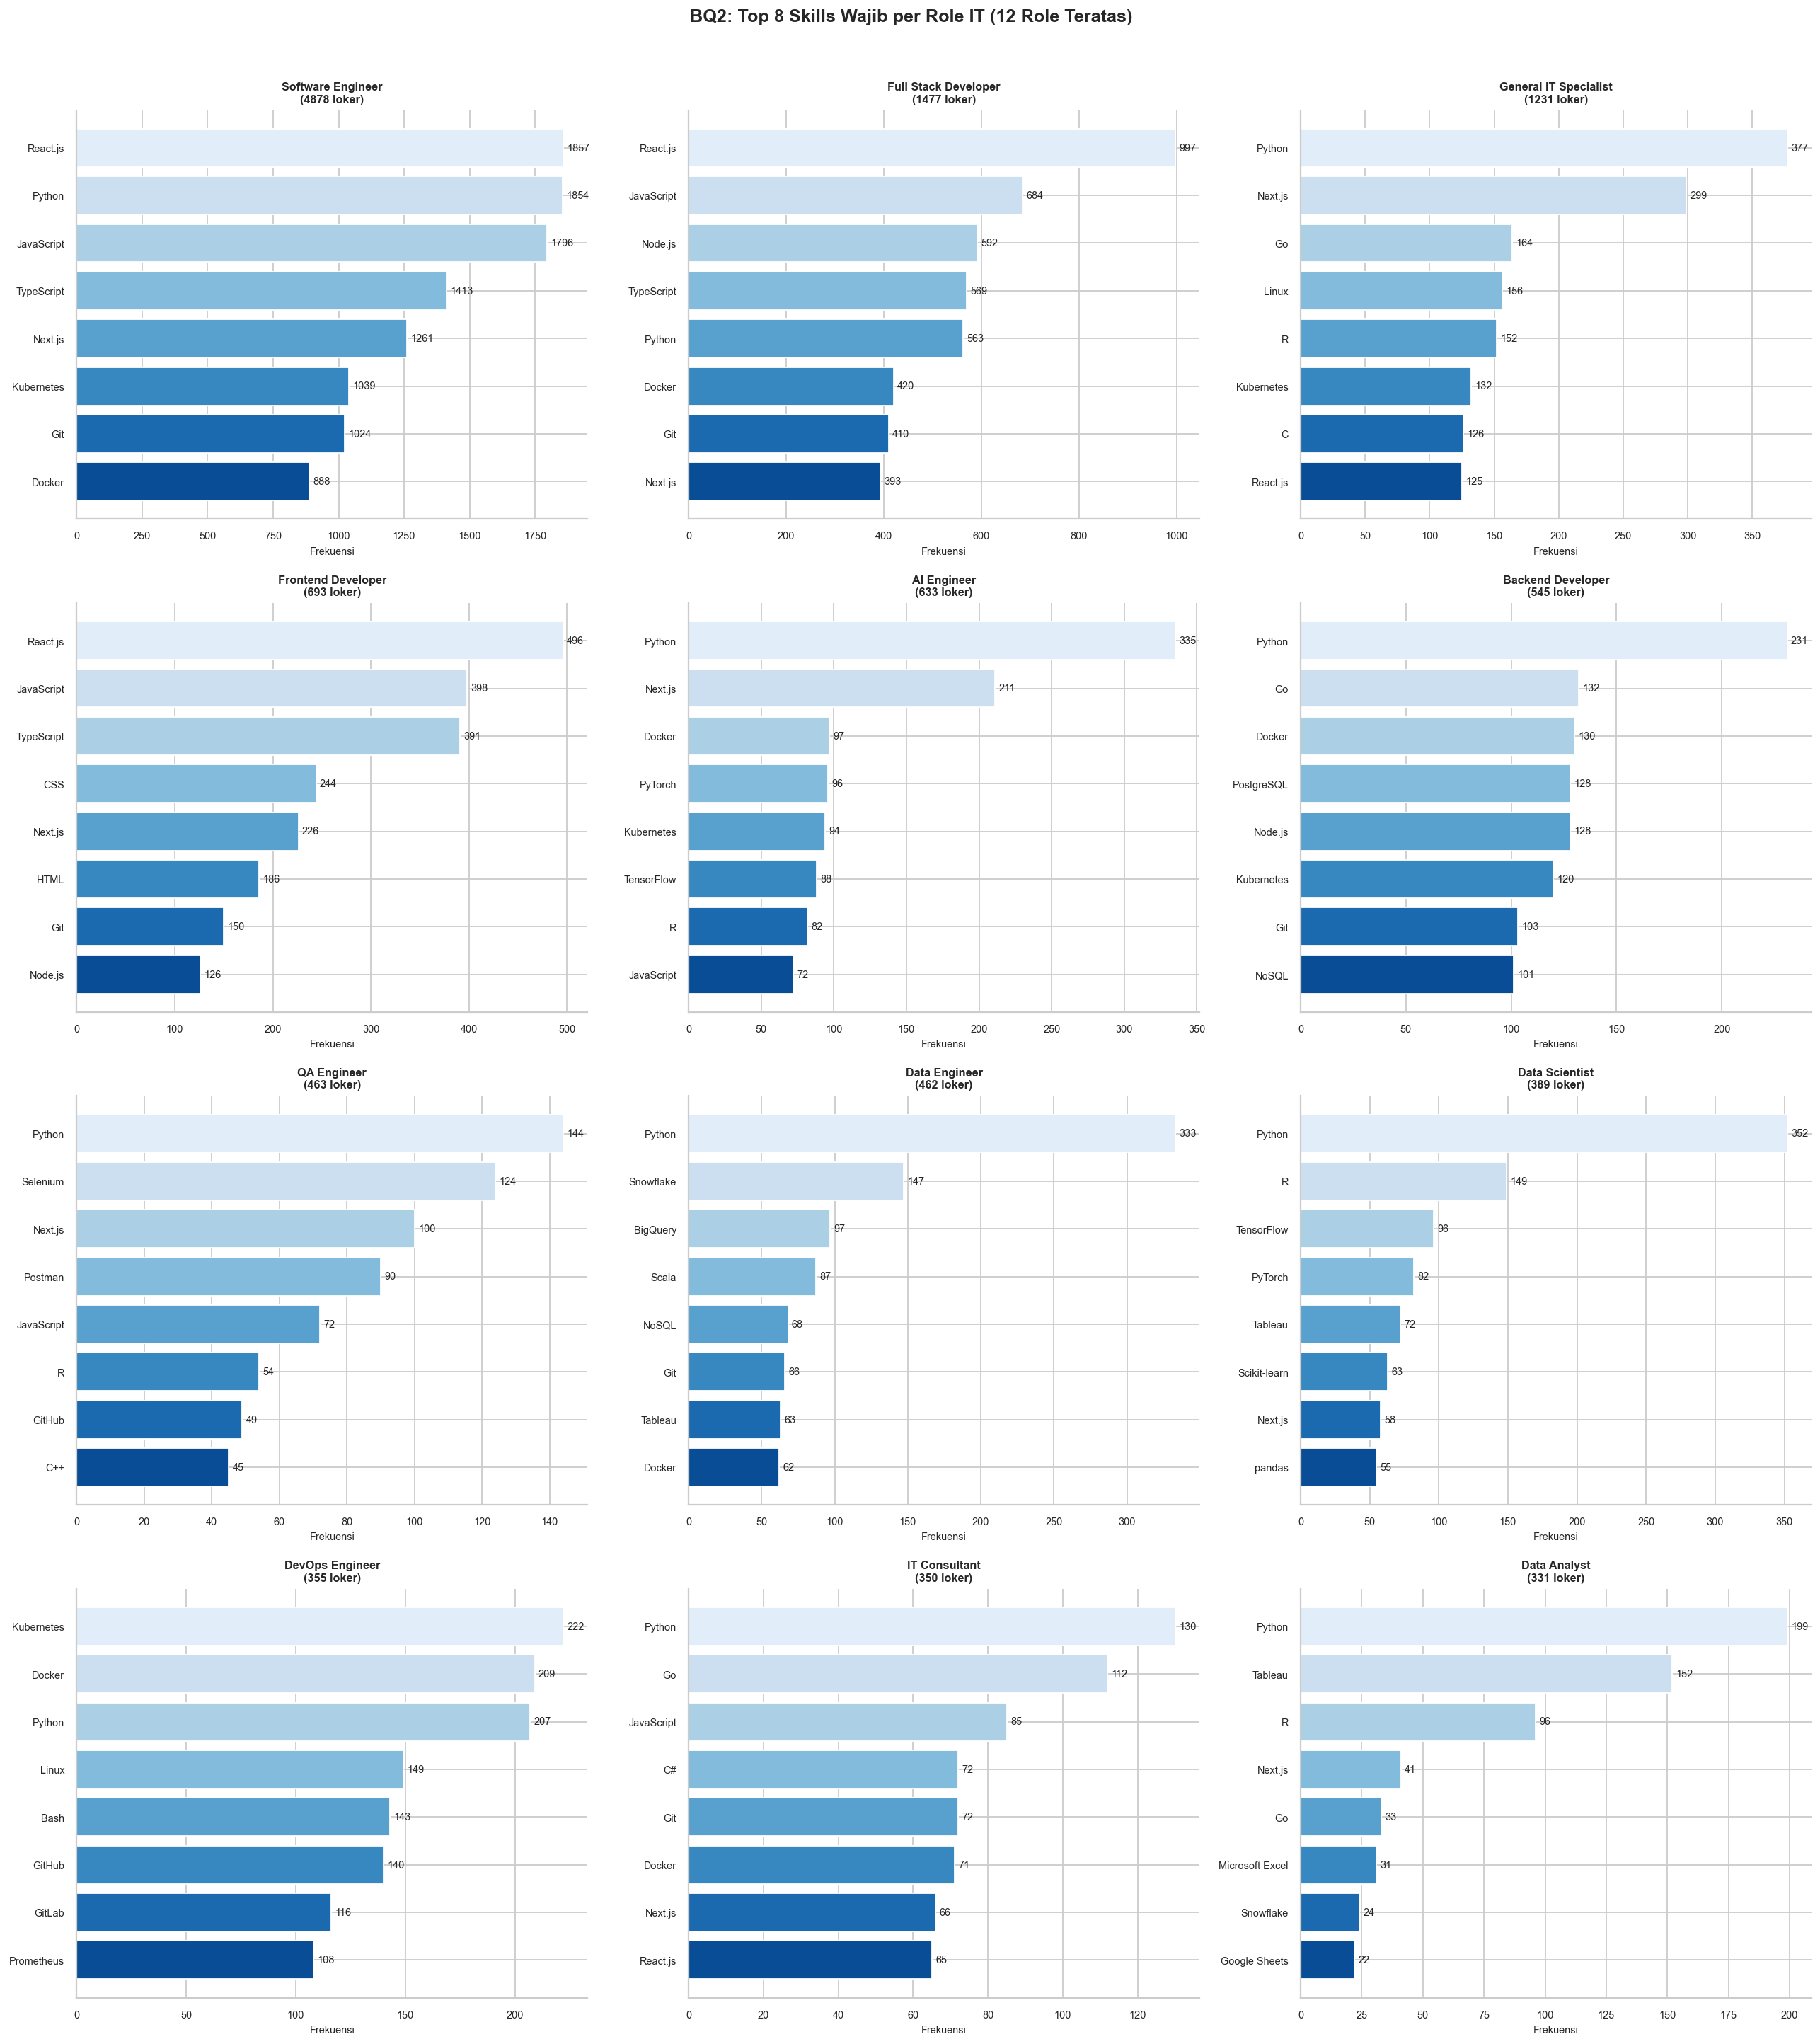

In [46]:
print('===== BQ2: Top Skills Wajib per Role IT =====')

def top_skills_role(role, n=7):
    skills = []
    df[df['role_label'] == role]['skills_list'].apply(lambda l: skills.extend(l))
    return pd.DataFrame(Counter(skills).most_common(n), columns=['skill', 'count'])

# Pilih top 12 role
top12_roles = df['role_label'].value_counts().head(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for i, role in enumerate(top12_roles):
    rsk = top_skills_role(role, n=8)
    ax  = axes[i]
    n_jobs = (df['role_label'] == role).sum()
    if rsk.empty:
        ax.text(0.5, 0.5, 'No data', ha='center')
        continue
    bars = ax.barh(rsk['skill'][::-1], rsk['count'][::-1],
                   color=sns.color_palette('Blues_r', len(rsk)))
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_title(f'{role}\n({n_jobs} loker)', fontweight='bold', fontsize=9)
    ax.set_xlabel('Frekuensi', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('BQ2: Top 8 Skills Wajib per Role IT (12 Role Teratas)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

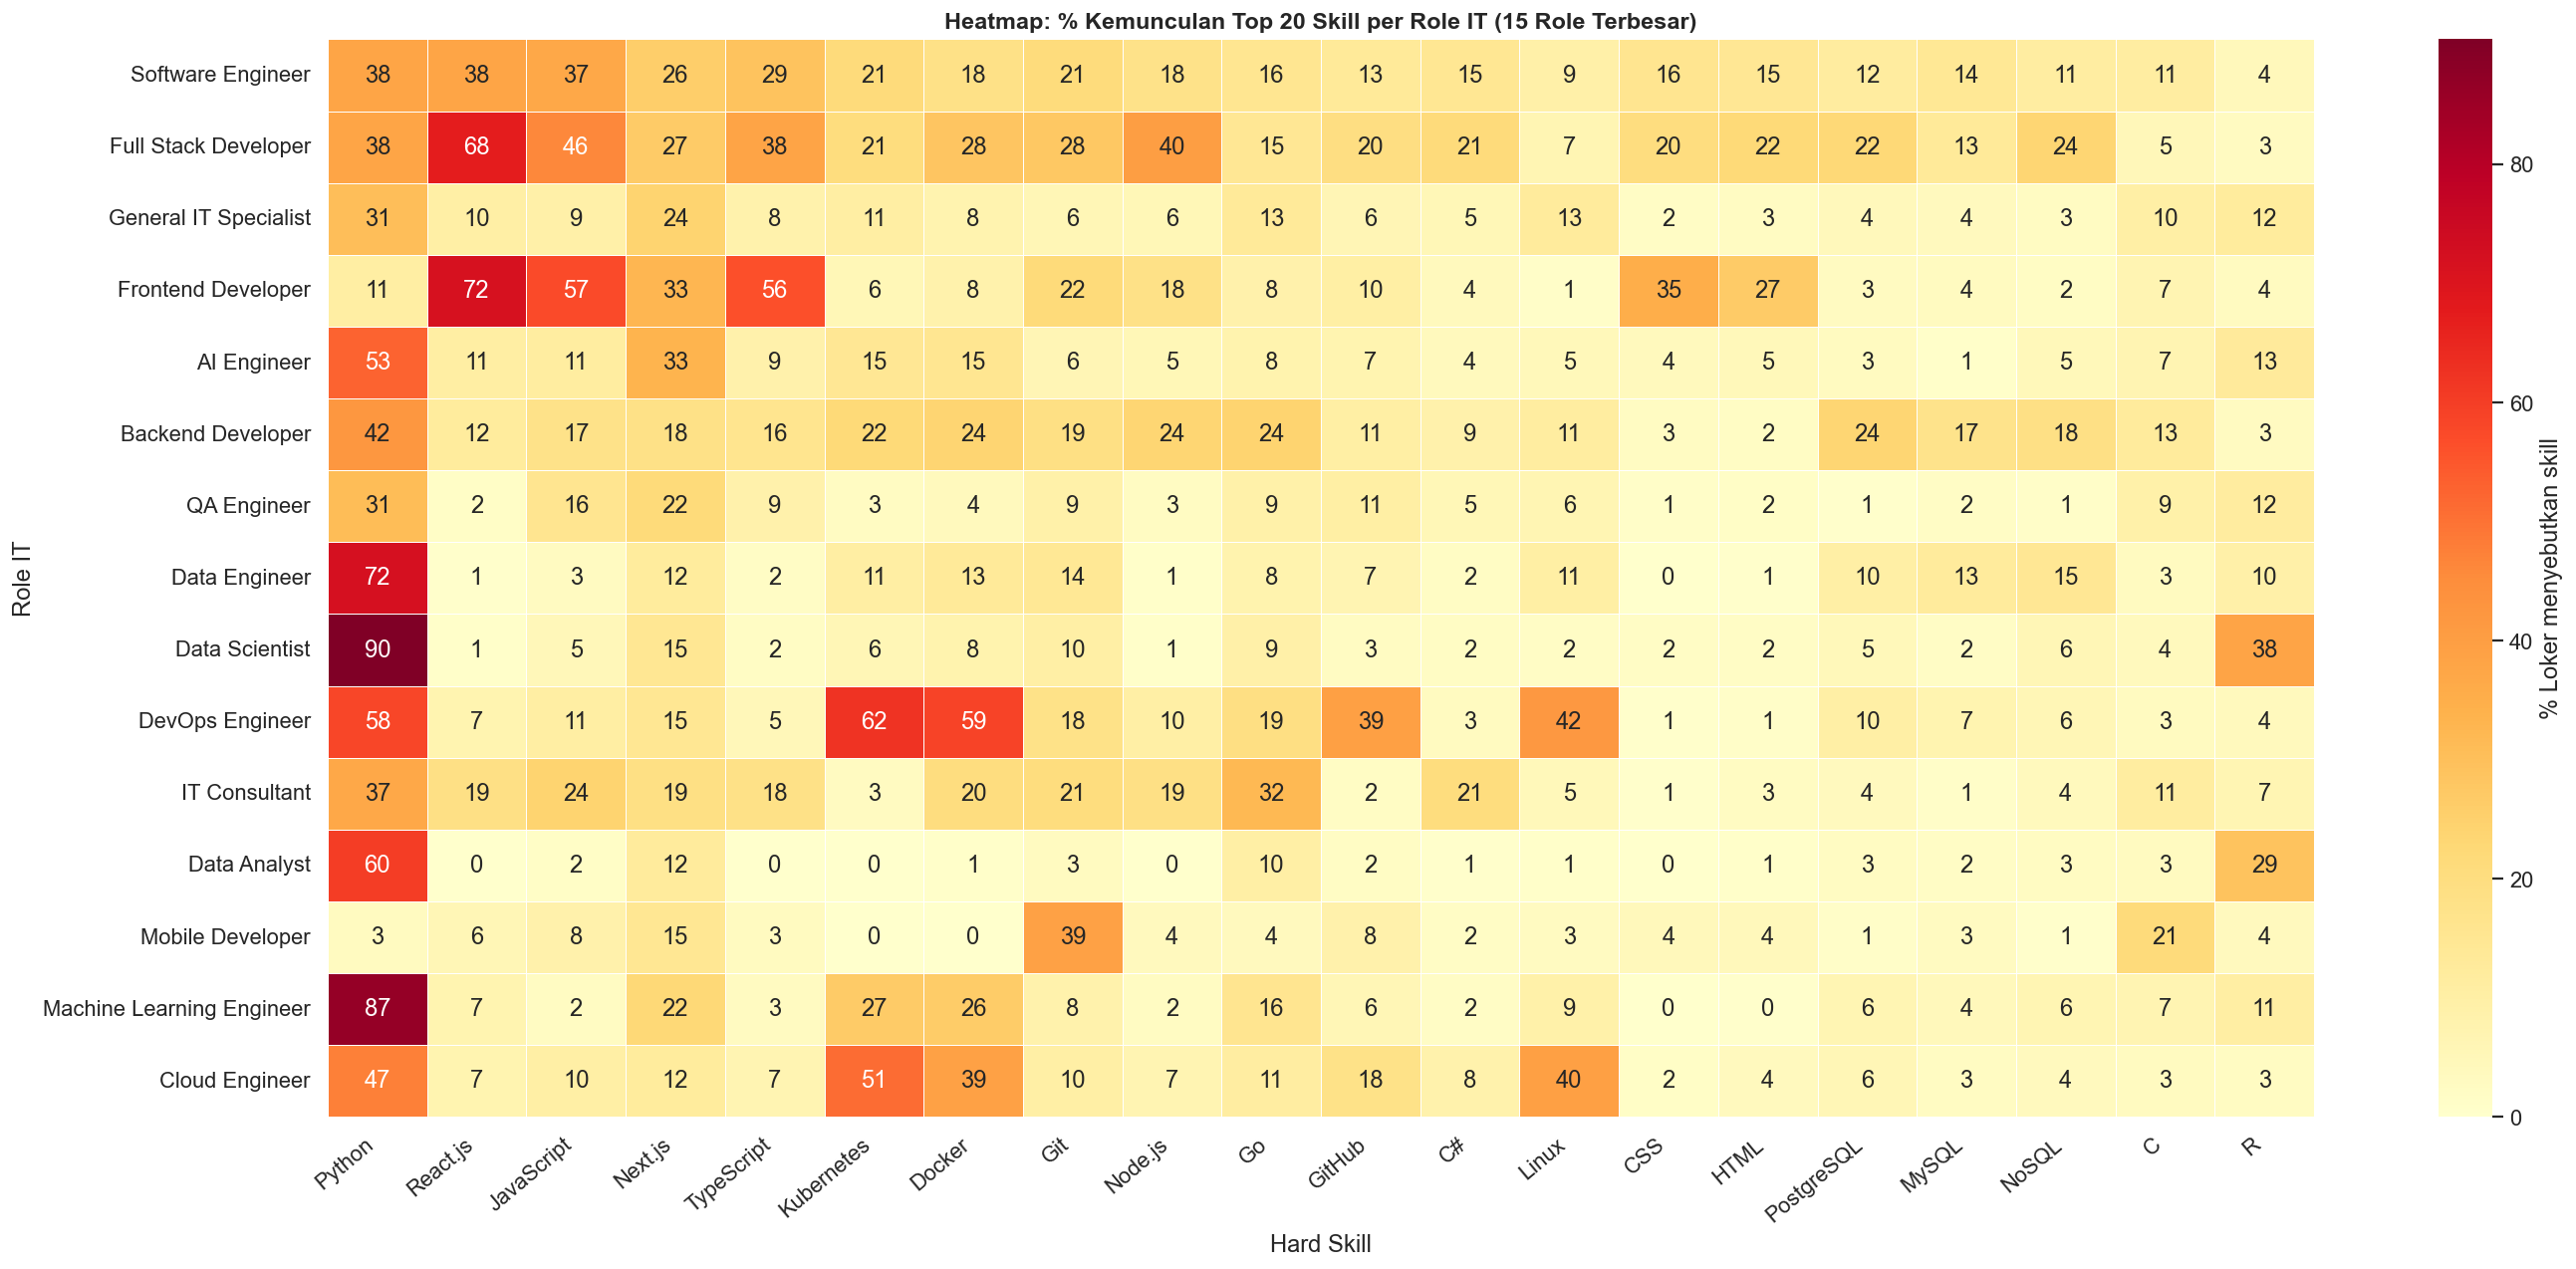

In [36]:
# ── Heatmap: % kemunculan top skill per role ──────────────────────────
top20_skills = [s for s, _ in skill_ctr.most_common(20)]
top15_roles  = df['role_label'].value_counts().head(15).index.tolist()

hm_data = {}
for role in top15_roles:
    df_r = df[df['role_label'] == role]
    total = len(df_r)
    row_skills = {}
    for skill in top20_skills:
        has = df_r['skills_list'].apply(lambda l: skill in l).sum()
        row_skills[skill] = round(has / total * 100, 1)
    hm_data[role] = row_skills

hm_df = pd.DataFrame(hm_data).T

fig, ax = plt.subplots(figsize=(22, 10))
sns.heatmap(hm_df, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% Loker menyebutkan skill'},
            ax=ax)
ax.set_title('Heatmap: % Kemunculan Top 20 Skill per Role IT (15 Role Terbesar)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hard Skill')
ax.set_ylabel('Role IT')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

---
## 6. BQ5 — Kompetisi Loker per Role

===== BQ5: Tingkat Kompetisi per Role =====


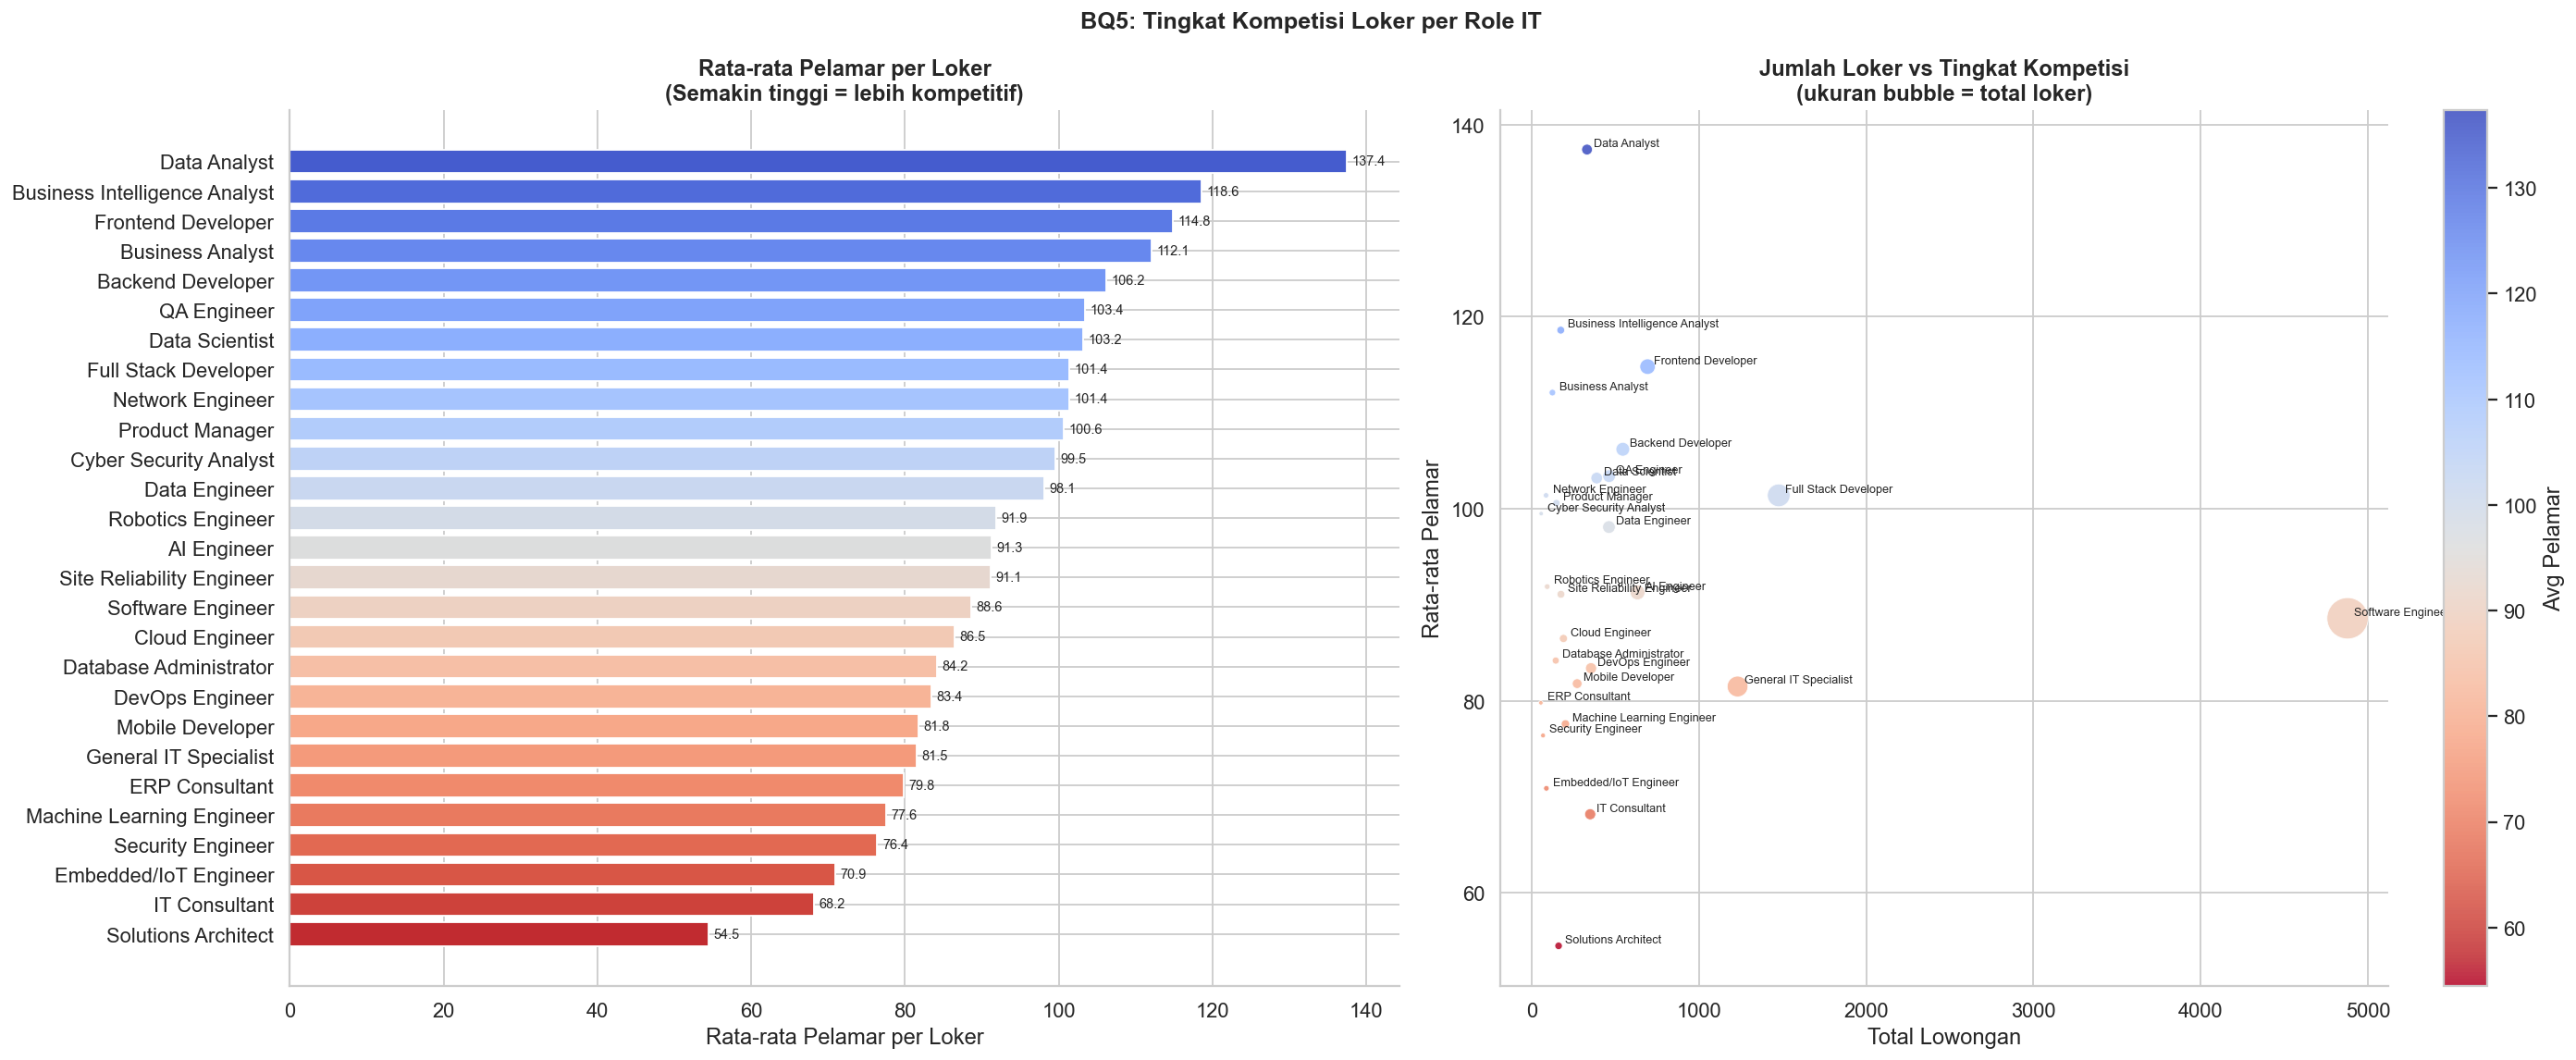

Role paling kompetitif : Data Analyst (137.4 pelamar/loker)
Role paling mudah masuk: Solutions Architect (54.5 pelamar/loker)


In [37]:
print('===== BQ5: Tingkat Kompetisi per Role =====')

comp = df.groupby('role_label').agg(
    avg_applicants    = ('applicantsCount', 'mean'),
    median_applicants = ('applicantsCount', 'median'),
    total_jobs        = ('role_label', 'count'),
).round(1).sort_values('avg_applicants', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Bar chart rata-rata pelamar
ax1 = axes[0]
pal = sns.color_palette('coolwarm_r', len(comp))
bars = ax1.barh(comp.index[::-1], comp['avg_applicants'][::-1], color=pal)
ax1.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
ax1.set_xlabel('Rata-rata Pelamar per Loker')
ax1.set_title('Rata-rata Pelamar per Loker\n(Semakin tinggi = lebih kompetitif)', fontweight='bold')

# Scatter: jumlah loker vs kompetisi
ax2 = axes[1]
sc = ax2.scatter(comp['total_jobs'], comp['avg_applicants'],
                 s=comp['total_jobs']/8, c=comp['avg_applicants'],
                 cmap='coolwarm_r', alpha=0.85, edgecolors='white', linewidth=0.5)
for role, row in comp.iterrows():
    ax2.annotate(role, (row['total_jobs'], row['avg_applicants']),
                 fontsize=7, ha='left', xytext=(4, 2), textcoords='offset points')
plt.colorbar(sc, ax=ax2, label='Avg Pelamar')
ax2.set_xlabel('Total Lowongan')
ax2.set_ylabel('Rata-rata Pelamar')
ax2.set_title('Jumlah Loker vs Tingkat Kompetisi\n(ukuran bubble = total loker)', fontweight='bold')

fig.suptitle('BQ5: Tingkat Kompetisi Loker per Role IT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Role paling kompetitif : {comp.index[0]} ({comp.iloc[0]["avg_applicants"]:.1f} pelamar/loker)')
print(f'Role paling mudah masuk: {comp.index[-1]} ({comp.iloc[-1]["avg_applicants"]:.1f} pelamar/loker)')

---
## 7. BQ6 — Distribusi Seniority & Skill per Level

===== BQ6: Distribusi Jenjang Karir =====


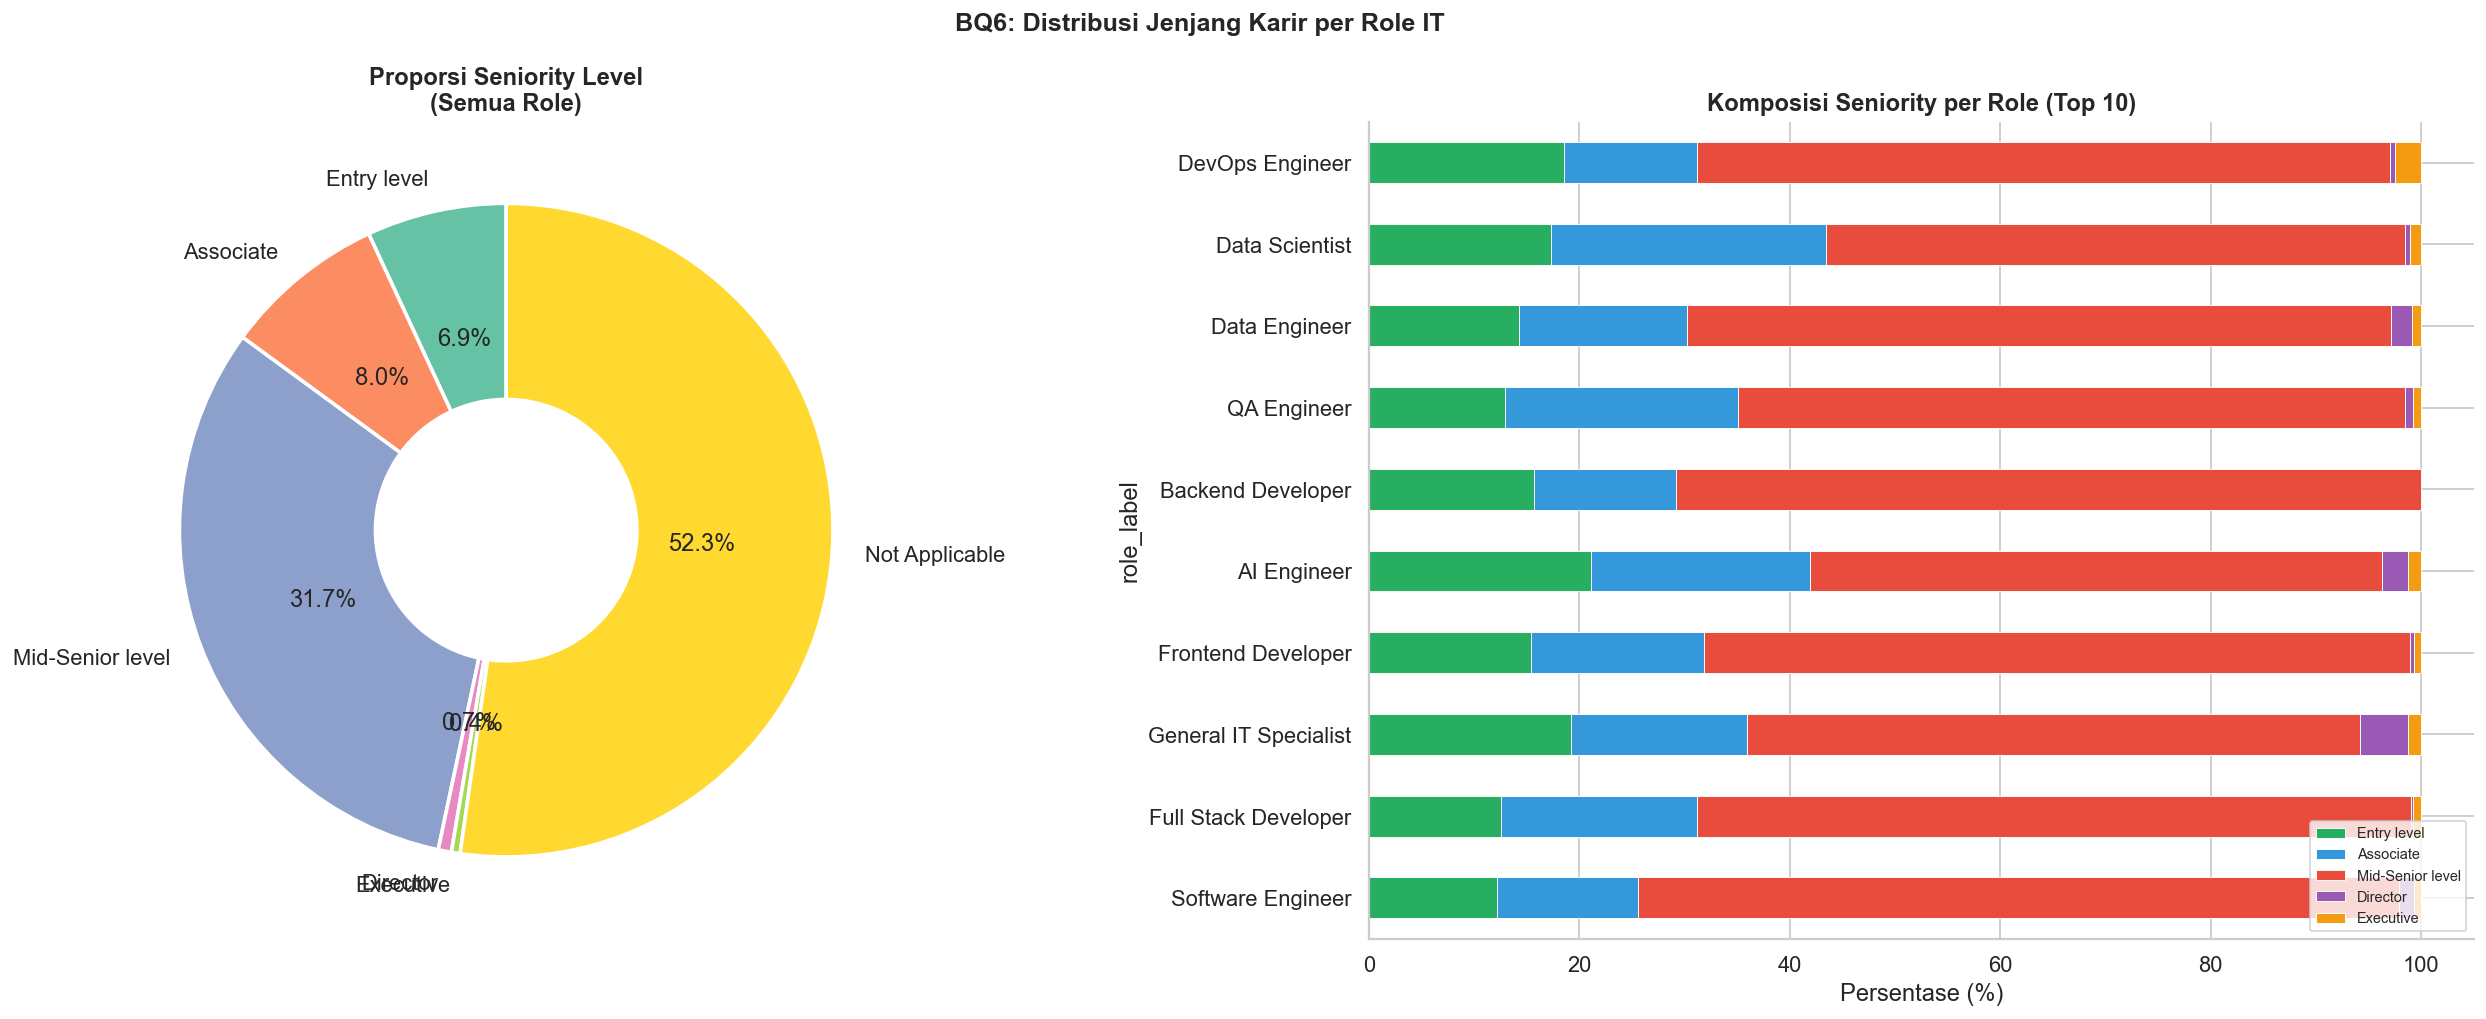

In [38]:
print('===== BQ6: Distribusi Jenjang Karir =====')

SEN_ORDER = ['Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive', 'Not Applicable']
sen_counts = df['seniorityLevel'].value_counts().reindex(SEN_ORDER, fill_value=0)

SEN_CORE = ['Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Donut chart
ax1 = axes[0]
ax1.pie(sen_counts.values, labels=sen_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Set2', len(sen_counts)),
        wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Proporsi Seniority Level\n(Semua Role)', fontweight='bold')

# Stacked bar per role
ax2 = axes[1]
df_core_sen = df[df['seniorityLevel'].isin(SEN_CORE)]
sen_role = df_core_sen.groupby(['role_label', 'seniorityLevel']).size().unstack(fill_value=0)
sen_pct  = sen_role.div(sen_role.sum(axis=1), axis=0) * 100
top10_by_size = df['role_label'].value_counts().head(10).index
sen_pct = sen_pct.reindex(top10_by_size)
existing = [c for c in SEN_CORE if c in sen_pct.columns]
sen_pct[existing].plot(kind='barh', stacked=True, ax=ax2,
                       color=['#27AE60','#3498DB','#E74C3C','#9B59B6','#F39C12'][:len(existing)],
                       edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Persentase (%)')
ax2.set_title('Komposisi Seniority per Role (Top 10)', fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)

fig.suptitle('BQ6: Distribusi Jenjang Karir per Role IT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

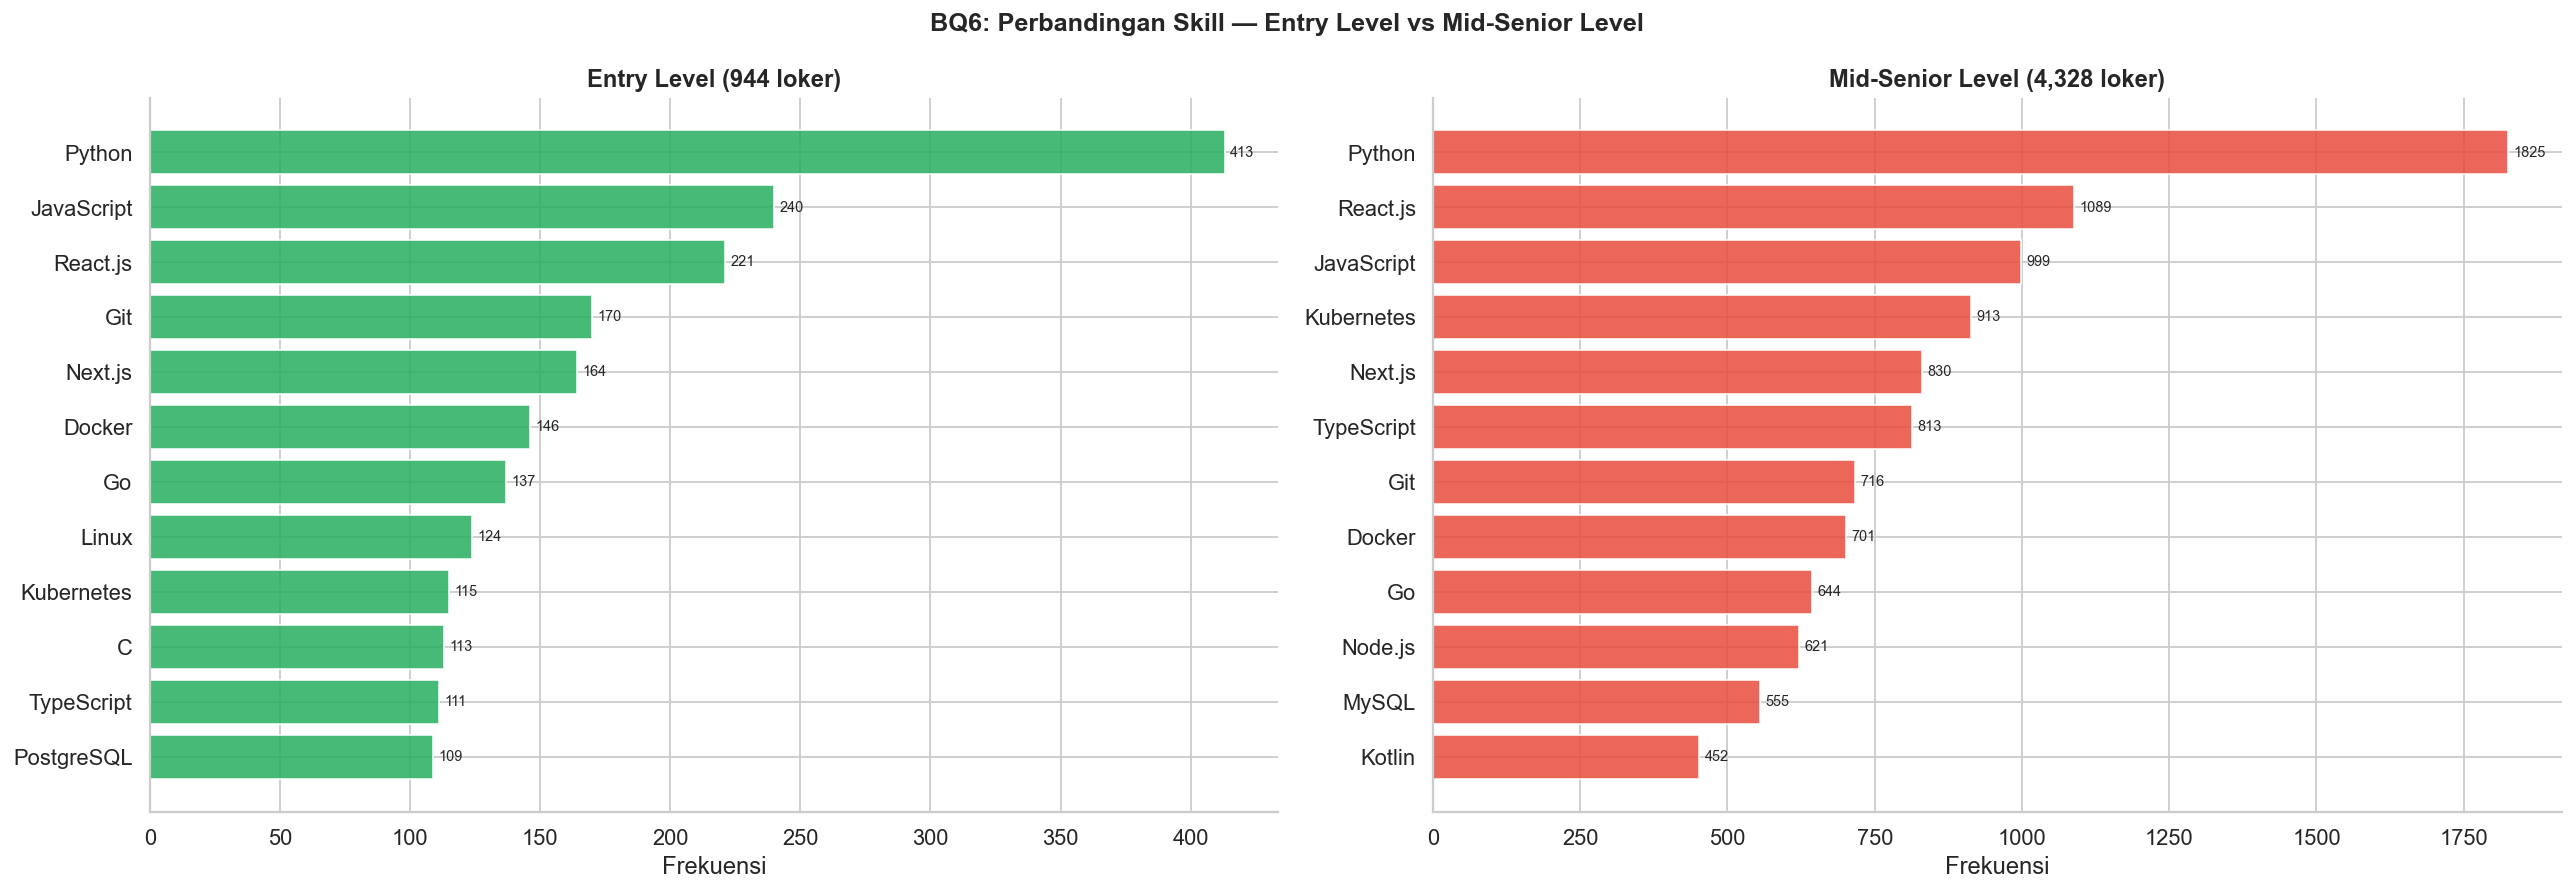

Skill khas Entry (tidak di Senior top-12) : {'C', 'Linux', 'PostgreSQL'}
Skill khas Senior (tidak di Entry top-12) : {'Node.js', 'Kotlin', 'MySQL'}


In [39]:
# ── Entry vs Mid-Senior skills ────────────────────────────────────────
def role_top_skills(df_sub, n=12):
    skills = []
    df_sub['skills_list'].apply(lambda l: skills.extend(l))
    return pd.DataFrame(Counter(skills).most_common(n), columns=['skill', 'count'])

df_entry  = df[df['seniorityLevel'] == 'Entry level']
df_senior = df[df['seniorityLevel'] == 'Mid-Senior level']

entry_top  = role_top_skills(df_entry)
senior_top = role_top_skills(df_senior)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, data, color, title in zip(
    axes,
    [entry_top, senior_top],
    ['#27AE60', '#E74C3C'],
    [f'Entry Level ({len(df_entry):,} loker)', f'Mid-Senior Level ({len(df_senior):,} loker)']
):
    bars = ax.barh(data['skill'][::-1], data['count'][::-1], color=color, alpha=0.85)
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frekuensi')

fig.suptitle('BQ6: Perbandingan Skill — Entry Level vs Mid-Senior Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Skill unik per level
entry_set  = set(entry_top['skill'])
senior_set = set(senior_top['skill'])
print(f'Skill khas Entry (tidak di Senior top-12) : {entry_set - senior_set}')
print(f'Skill khas Senior (tidak di Entry top-12) : {senior_set - entry_set}')

---
## 8. BQ7 — Adopsi Remote Work

===== BQ7: Adopsi Remote Work di IT =====


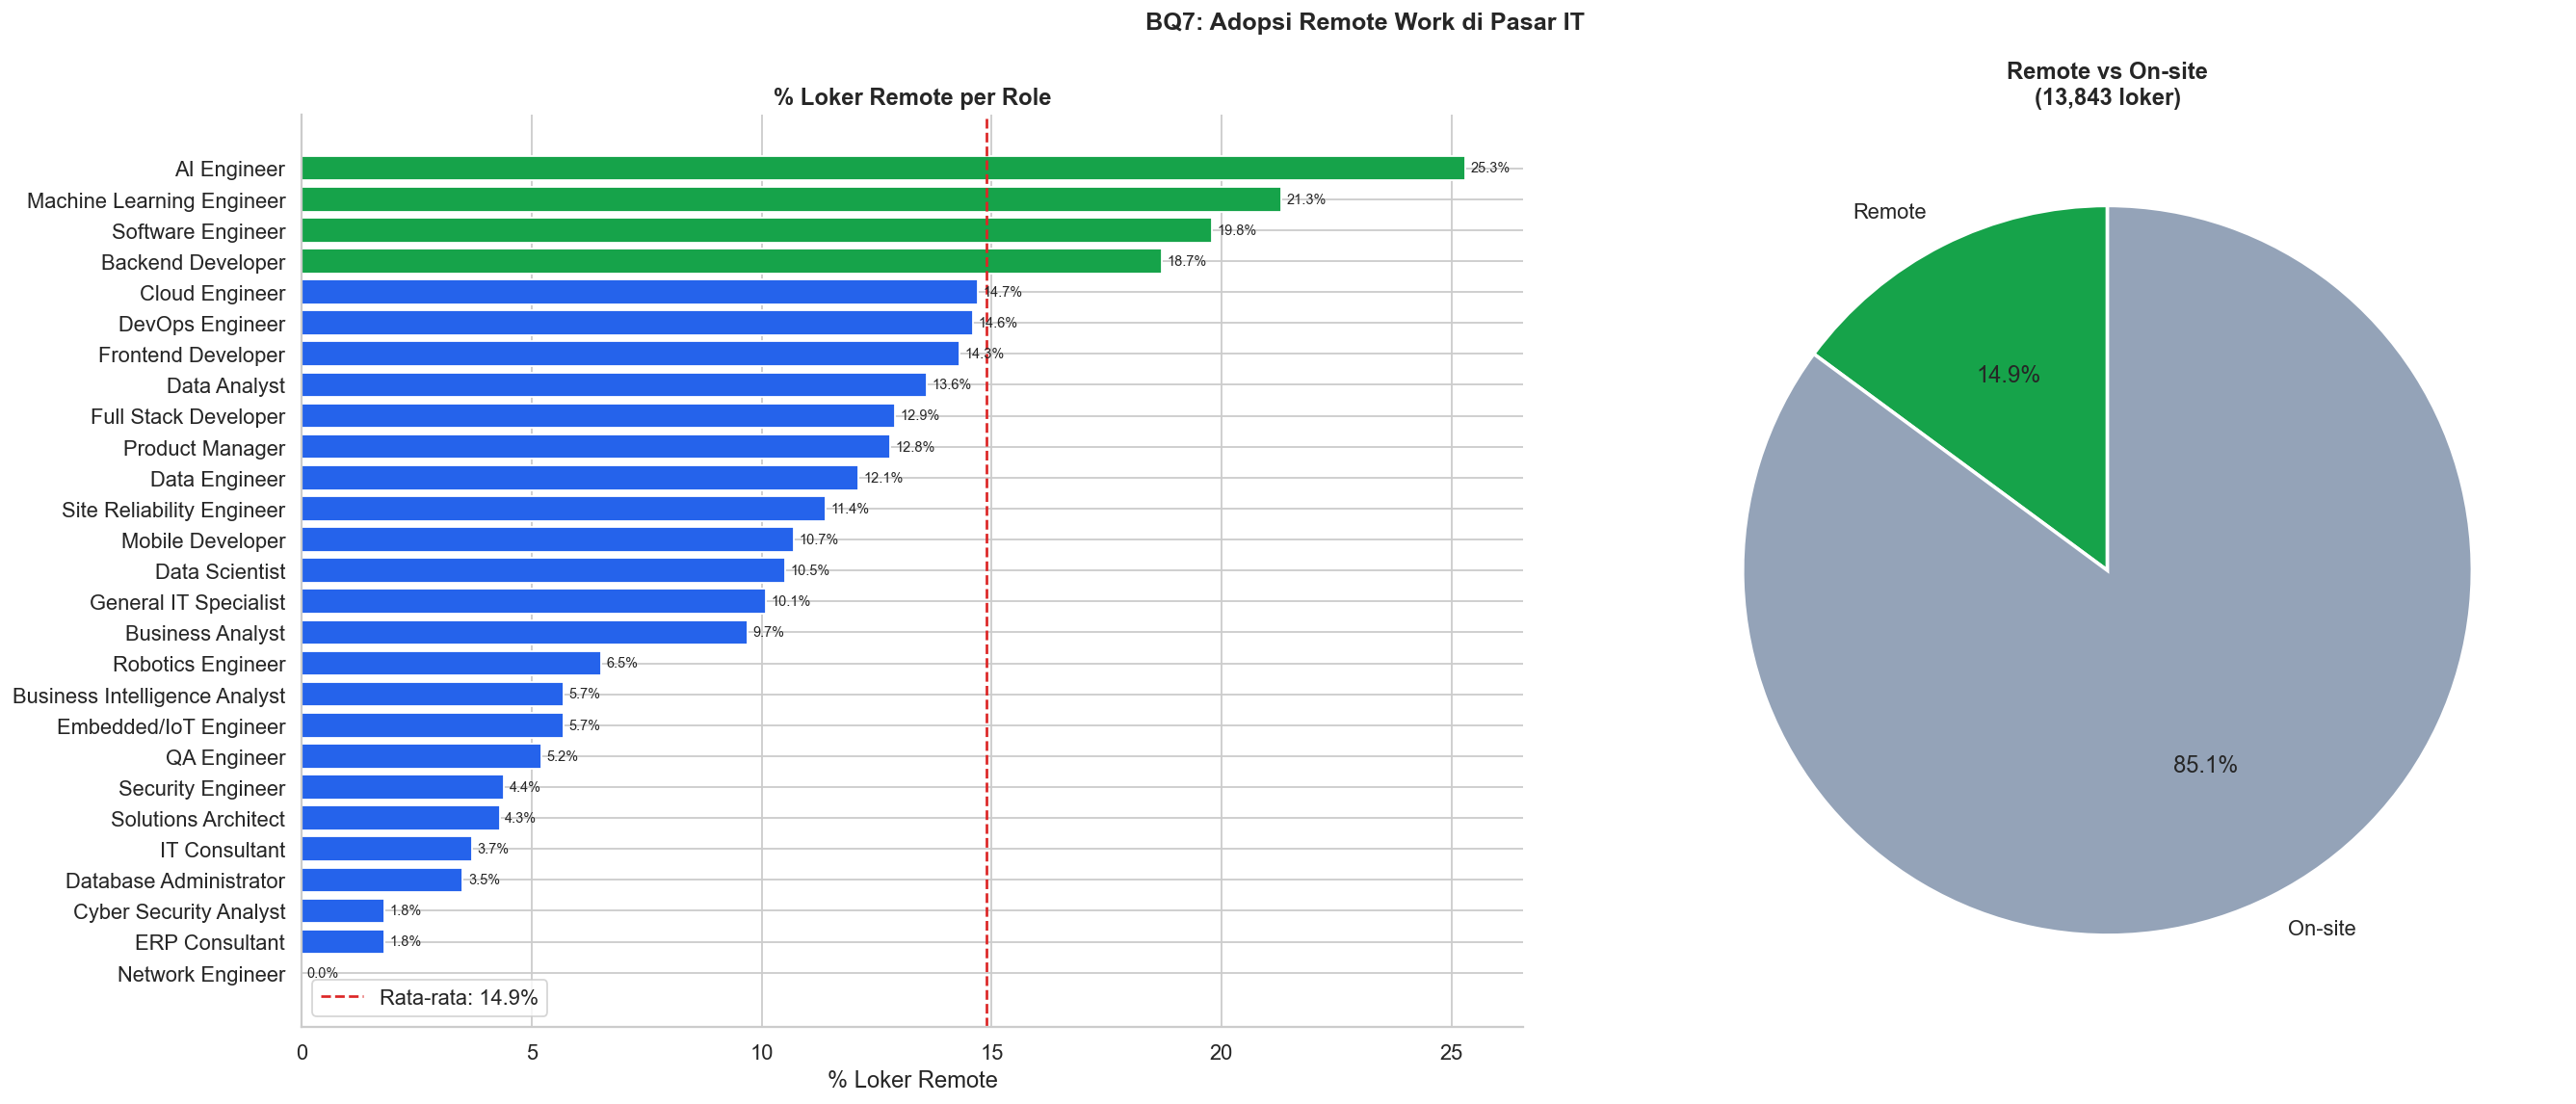

Rata-rata adopsi remote : 14.9%
Paling remote-friendly  : AI Engineer (25.3%)
Paling sedikit remote   : Network Engineer (0.0%)


In [48]:
print('===== BQ7: Adopsi Remote Work di IT =====')

df_rm = df.dropna(subset=['workRemoteAllowed']).copy()
df_rm['is_remote'] = df_rm['workRemoteAllowed'].astype(float).astype(bool)

remote_role = df_rm.groupby('role_label').agg(
    total  = ('is_remote', 'count'),
    remote = ('is_remote', 'sum'),
).assign(pct=lambda x: (x['remote'] / x['total'] * 100).round(1))\
  .sort_values('pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

ax1 = axes[0]
avg_remote = df_rm['is_remote'].mean() * 100
colors_rm = [C_SUCCESS if v > avg_remote else C_PRIMARY for v in remote_role['pct']]
bars = ax1.barh(remote_role.index[::-1], remote_role['pct'][::-1], color=colors_rm[::-1])
ax1.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax1.axvline(avg_remote, color=C_DANGER, linestyle='--', linewidth=1.5,
            label=f'Rata-rata: {avg_remote:.1f}%')
ax1.set_xlabel('% Loker Remote')
ax1.set_title('% Loker Remote per Role', fontweight='bold')
ax1.legend()

ax2 = axes[1]
rv = df_rm['is_remote'].value_counts()
ax2.pie([rv.get(True, 0), rv.get(False, 0)],
        labels=['Remote', 'On-site'],
        autopct='%1.1f%%',
        colors=[C_SUCCESS, C_LIGHT],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title(f'Remote vs On-site\n({len(df_rm):,} loker)', fontweight='bold')

fig.suptitle('BQ7: Adopsi Remote Work di Pasar IT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Rata-rata adopsi remote : {avg_remote:.1f}%')
print(f'Paling remote-friendly  : {remote_role.index[0]} ({remote_role.iloc[0]["pct"]:.1f}%)')
print(f'Paling sedikit remote   : {remote_role.index[-1]} ({remote_role.iloc[-1]["pct"]:.1f}%)')

---
## 9. Analisis Tambahan: Tren Loker & Employment Type

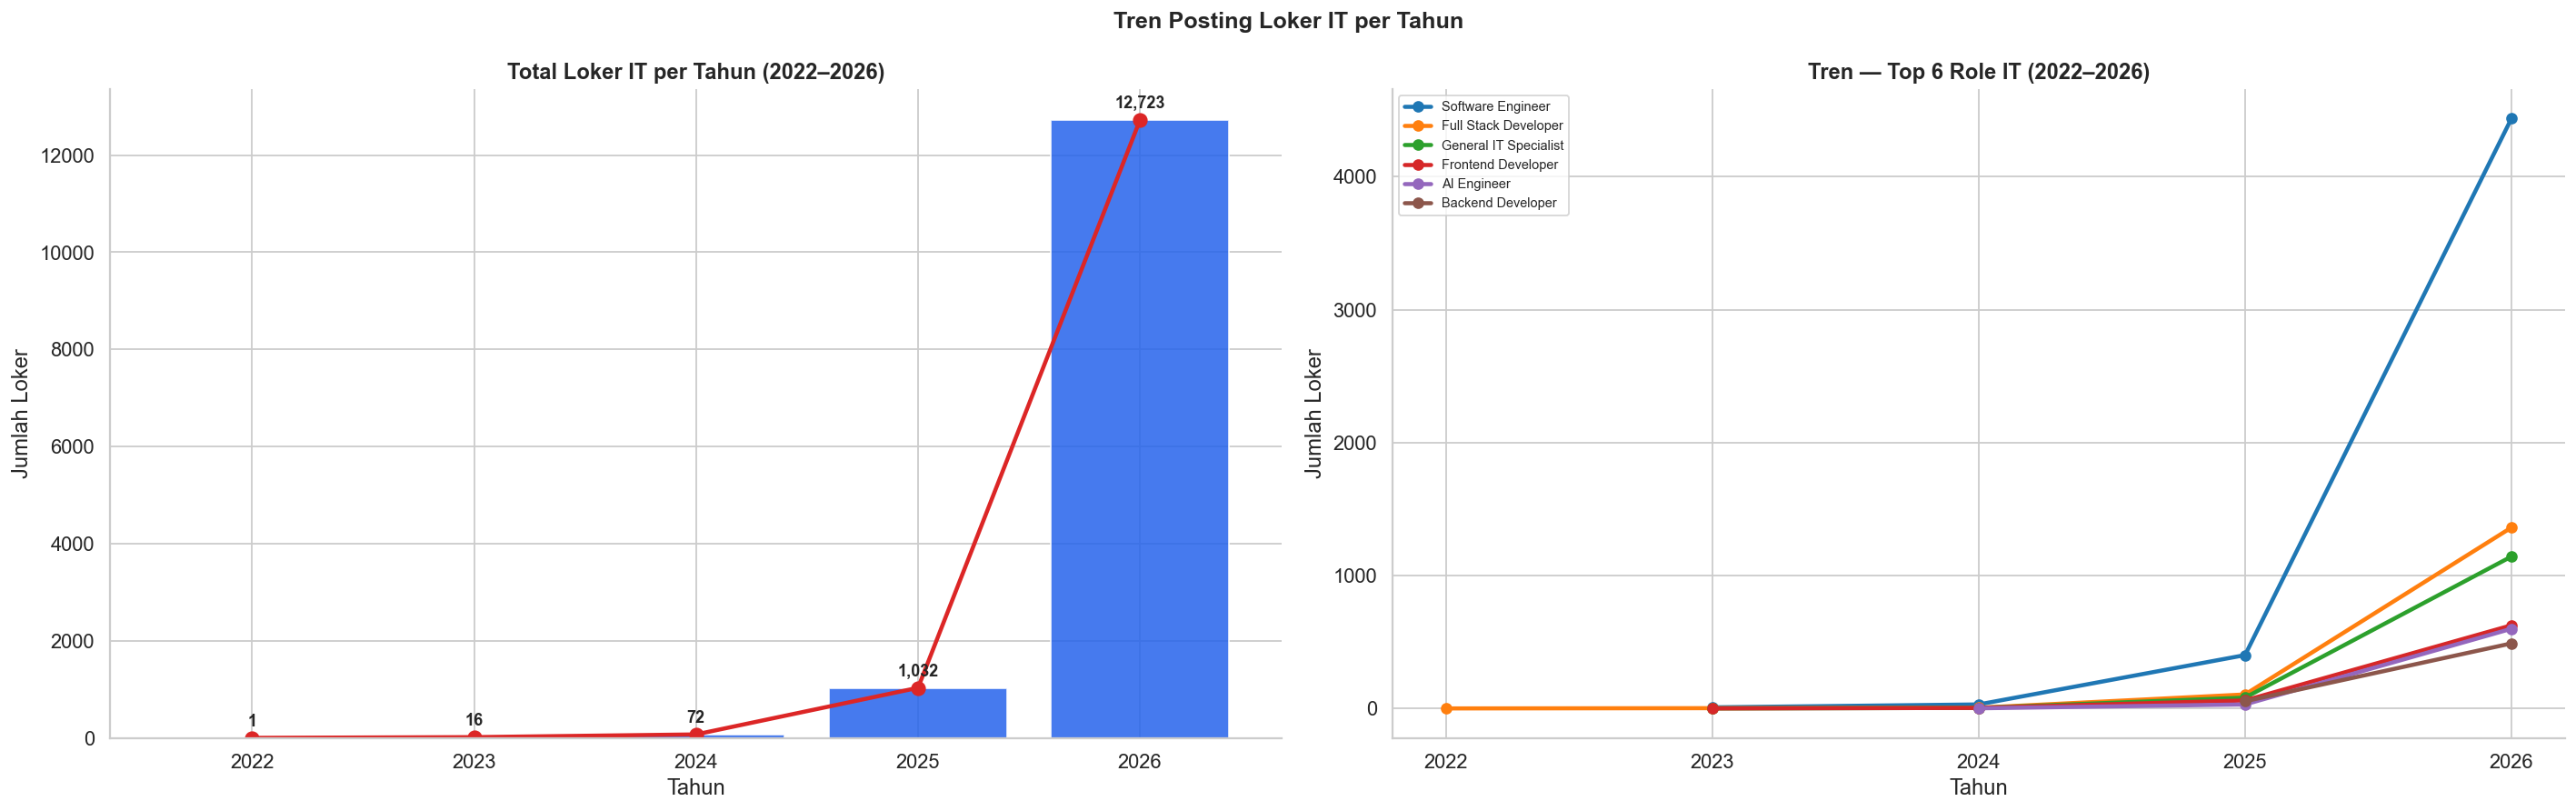

In [41]:
# ── Tren jumlah loker per tahun ───────────────────────────────────────
yearly = df[df['year'].between(2022, 2026)].groupby('year').size().reset_index(name='count')

top6 = df['role_label'].value_counts().head(6).index
ry   = df[df['role_label'].isin(top6) & df['year'].between(2022, 2026)]\
         .groupby(['year', 'role_label']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

ax1 = axes[0]
ax1.bar(yearly['year'], yearly['count'], color=C_PRIMARY, alpha=0.85, edgecolor='white')
ax1.plot(yearly['year'], yearly['count'], marker='o', color=C_DANGER, linewidth=2.5, markersize=8)
for _, r in yearly.iterrows():
    ax1.annotate(f"{int(r['count']):,}", (r['year'], r['count']),
                 ha='center', va='bottom', fontsize=10, fontweight='bold',
                 xytext=(0, 5), textcoords='offset points')
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Jumlah Loker')
ax1.set_title('Total Loker IT per Tahun (2022–2026)', fontweight='bold')
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2 = axes[1]
pal6 = sns.color_palette('tab10', 6)
for i, role in enumerate(top6):
    d = ry[ry['role_label'] == role]
    ax2.plot(d['year'], d['count'], marker='o', linewidth=2.5, label=role, color=pal6[i])
ax2.set_xlabel('Tahun')
ax2.set_ylabel('Jumlah Loker')
ax2.set_title('Tren — Top 6 Role IT (2022–2026)', fontweight='bold')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('Tren Posting Loker IT per Tahun', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

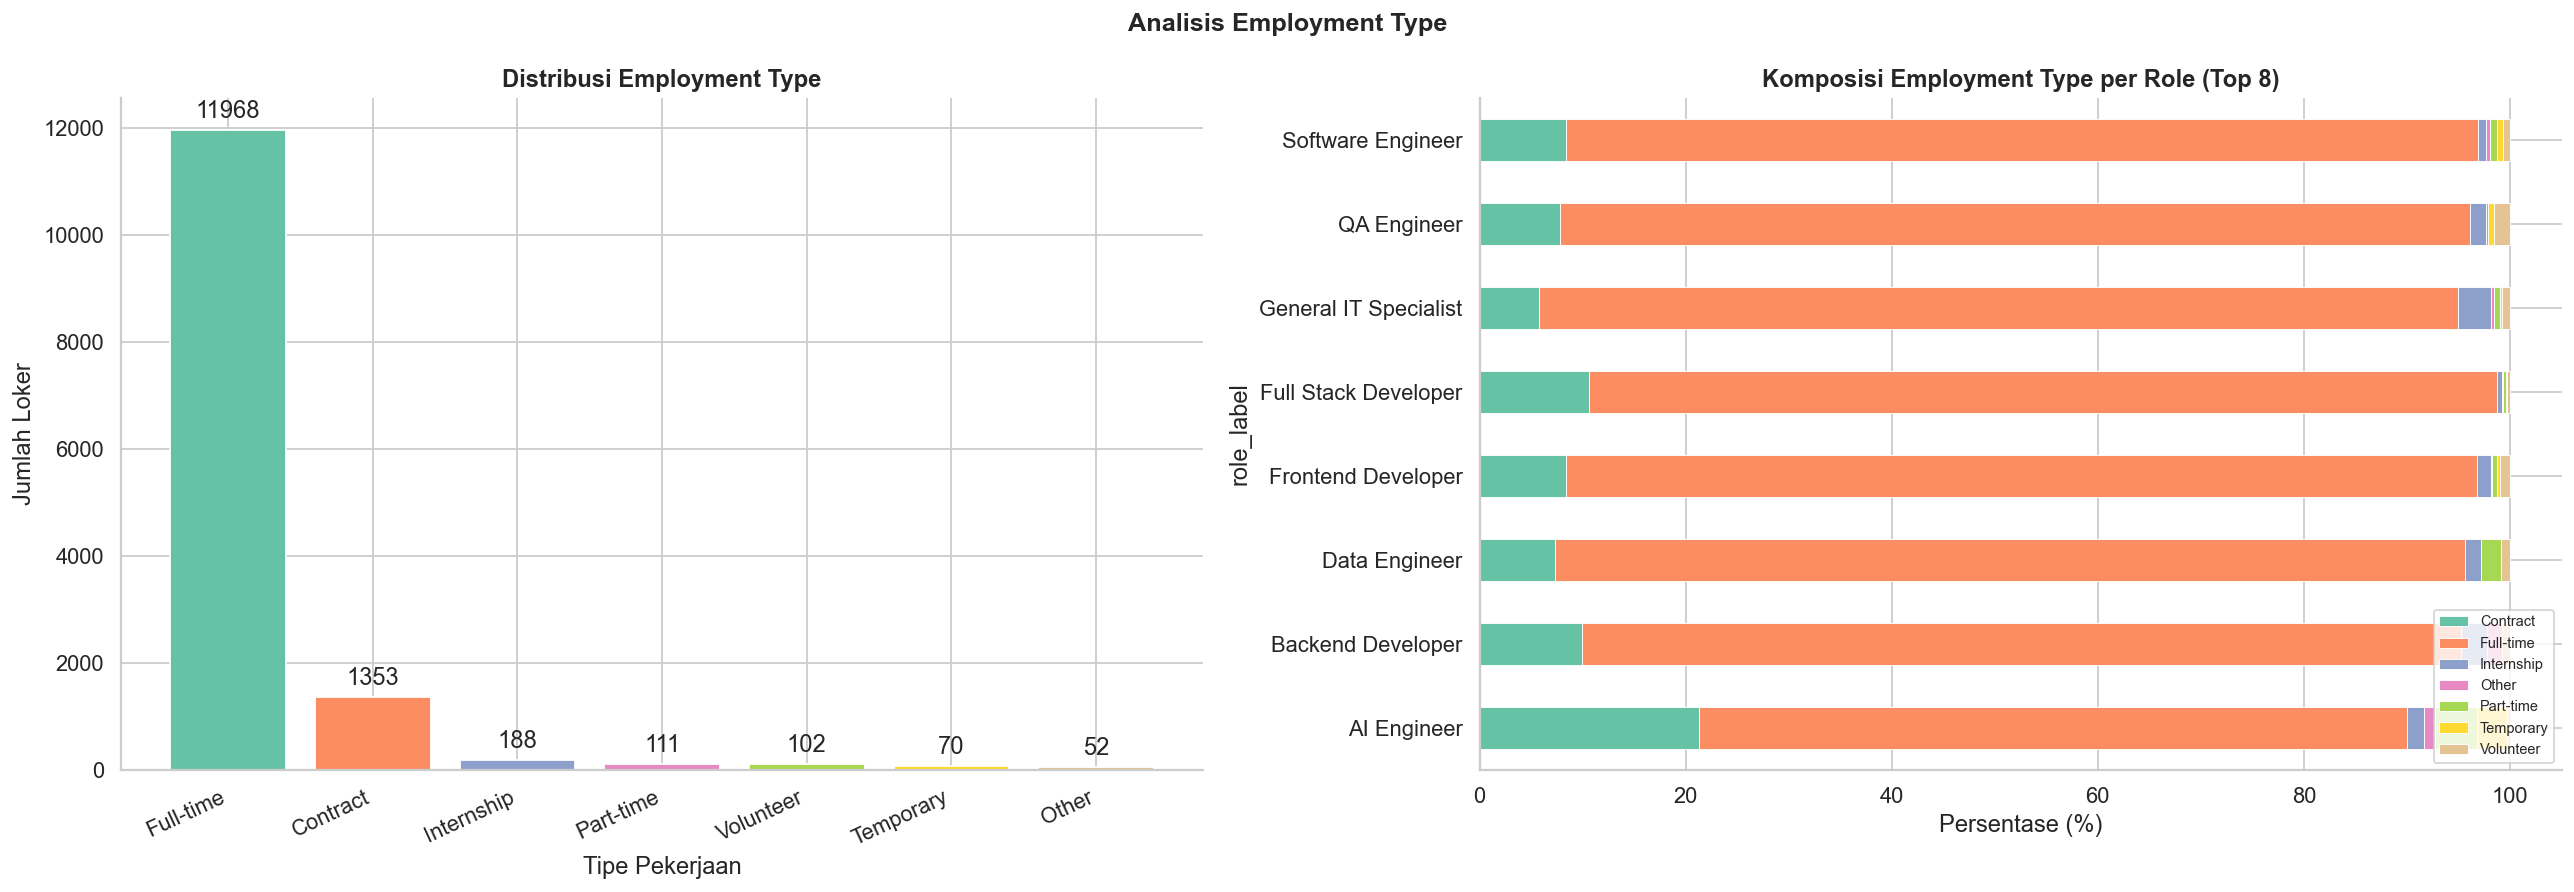

In [42]:
# ── Employment Type ───────────────────────────────────────────────────
emp_counts = df['employmentType'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ax1 = axes[0]
bars = ax1.bar(emp_counts.index, emp_counts.values,
               color=sns.color_palette('Set2', len(emp_counts)), edgecolor='white')
ax1.bar_label(bars, padding=4)
ax1.set_xlabel('Tipe Pekerjaan')
ax1.set_ylabel('Jumlah Loker')
ax1.set_title('Distribusi Employment Type', fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=25, ha='right')

ax2 = axes[1]
top8 = df['role_label'].value_counts().head(8).index
emp_r = df[df['role_label'].isin(top8)].groupby(['role_label','employmentType']).size().unstack(fill_value=0)
emp_r_pct = emp_r.div(emp_r.sum(axis=1), axis=0) * 100
emp_r_pct.plot(kind='barh', stacked=True, ax=ax2,
               color=sns.color_palette('Set2', len(emp_r_pct.columns)),
               edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Persentase (%)')
ax2.set_title('Komposisi Employment Type per Role (Top 8)', fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)

fig.suptitle('Analisis Employment Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

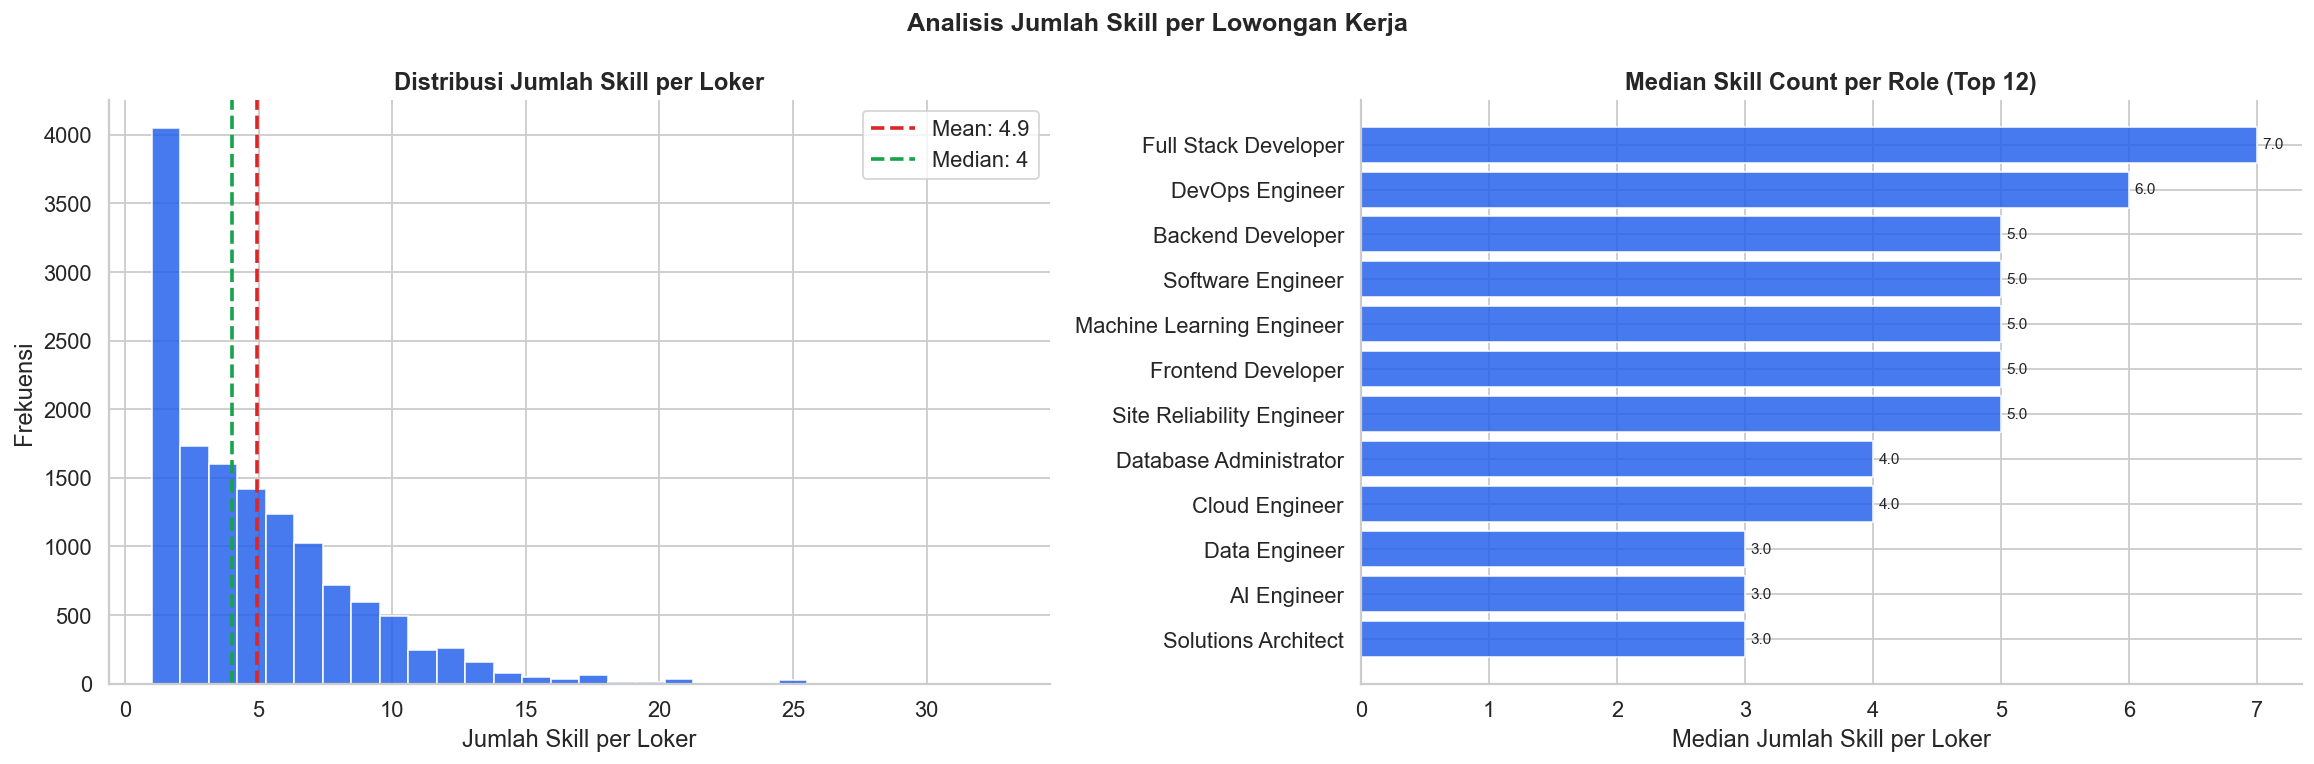

In [43]:
# ── Distribusi jumlah skill per loker ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
ax1.hist(df['skill_count'], bins=30, color=C_PRIMARY, edgecolor='white', alpha=0.85)
ax1.axvline(df['skill_count'].mean(), color=C_DANGER, linestyle='--', linewidth=2,
            label=f'Mean: {df["skill_count"].mean():.1f}')
ax1.axvline(df['skill_count'].median(), color=C_SUCCESS, linestyle='--', linewidth=2,
            label=f'Median: {df["skill_count"].median():.0f}')
ax1.set_xlabel('Jumlah Skill per Loker')
ax1.set_ylabel('Frekuensi')
ax1.set_title('Distribusi Jumlah Skill per Loker', fontweight='bold')
ax1.legend()

ax2 = axes[1]
med_per_role = df.groupby('role_label')['skill_count'].median().sort_values(ascending=False).head(12)
bars = ax2.barh(med_per_role.index[::-1], med_per_role.values[::-1], color=C_PRIMARY, alpha=0.85)
ax2.bar_label(bars, fmt='%.1f', padding=3, fontsize=8.5)
ax2.set_xlabel('Median Jumlah Skill per Loker')
ax2.set_title('Median Skill Count per Role (Top 12)', fontweight='bold')

fig.suptitle('Analisis Jumlah Skill per Lowongan Kerja', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Ringkasan EDA & Rekomendasi

In [44]:
rc_final = df['role_label'].value_counts()
comp2 = df.groupby('role_label')['applicantsCount'].mean().sort_values(ascending=False)
remote_avg = df.dropna(subset=['workRemoteAllowed'])['workRemoteAllowed'].astype(float).mean() * 100

print('='*65)
print('  RINGKASAN EDA — IT SKILLS GAP ANALYSIS')
print('='*65)
print(f"""
DATASET
  Input  : JOBS_WITH_EXTRACTED_SKILLS.csv ({len(df_raw):,} baris, 50 roles)
  Output : MASTERED_DATA_FINAL_MODELING.csv ({len(df):,} baris, {df['role_label'].nunique()} roles)
  Skill extraction: FlashText + O*NET dictionary (proper casing)

BQ1 - SKILL PALING DIMINATI
  Top 5 skill bersih: {', '.join([s for s,_ in skill_ctr.most_common(5)])}
  Total skill unik  : {len(skill_ctr)}
  Noise dihapus     : Analyze, REDUCE, Programming languages, dll.

BQ2 - SKILL WAJIB PER ROLE
  Setiap role memiliki 3-5 skill core yang muncul di >30% loker.
  Heatmap menunjukkan skill overlap tinggi pada role serupa.

BQ3 - MISSING SKILLS
  {df_raw['is_no_skill'].sum():,} loker ({df_raw['is_no_skill'].mean()*100:.1f}%) tanpa skill terdeteksi.
  Solusi: Drop loker tanpa skill untuk menjaga kualitas training.

BQ4 - IMBALANCE
  Sebelum: {rc_raw.max()/rc_raw.min():.0f}x (50 roles, termasuk Non-IT)
  Sesudah: {rc_final.max()/rc_final.min():.1f}x ({df['role_label'].nunique()} IT roles)
  13 role Non-IT di-drop, 10 role kecil di-merge.
  {(rc_final < 100).sum()} role masih < 100 loker -> gunakan class_weight='balanced'.

BQ5 - KOMPETISI
  Role paling kompetitif: {comp2.index[0]} ({comp2.iloc[0]:.1f} pelamar/loker)
  Role paling rendah kompetisi: {comp2.index[-1]} ({comp2.iloc[-1]:.1f} pelamar/loker)

BQ6 - SENIORITY
  Mayoritas loker: Mid-Senior level.
  Skill Entry vs Senior berbeda signifikan (lebih spesifik di Senior).

BQ7 - REMOTE WORK
  Adopsi remote masih rendah ({remote_avg:.1f}%).
  Role berbasis cloud/AI lebih cenderung menawarkan remote.

LANGKAH SELANJUTNYA
  1. Gunakan MASTERED_DATA_FINAL_MODELING.csv untuk training.
  2. Representasikan hard_skills dengan MultiLabelBinarizer atau TF-IDF.
  3. Terapkan class_weight='balanced' pada classifier.
  4. Model rekomendasi: Cosine Similarity atau Multi-label classifier.
""")
print('='*65)

  RINGKASAN EDA — IT SKILLS GAP ANALYSIS

DATASET
  Input  : JOBS_WITH_EXTRACTED_SKILLS.csv (18,768 baris, 50 roles)
  Output : MASTERED_DATA_FINAL_MODELING.csv (13,844 baris, 27 roles)
  Skill extraction: FlashText + O*NET dictionary (proper casing)

BQ1 - SKILL PALING DIMINATI
  Top 5 skill bersih: Python, React.js, JavaScript, Next.js, TypeScript
  Total skill unik  : 494
  Noise dihapus     : Analyze, REDUCE, Programming languages, dll.

BQ2 - SKILL WAJIB PER ROLE
  Setiap role memiliki 3-5 skill core yang muncul di >30% loker.
  Heatmap menunjukkan skill overlap tinggi pada role serupa.

BQ3 - MISSING SKILLS
  3,702 loker (19.7%) tanpa skill terdeteksi.
  Solusi: Drop loker tanpa skill untuk menjaga kualitas training.

BQ4 - IMBALANCE
  Sebelum: 5019x (50 roles, termasuk Non-IT)
  Sesudah: 88.7x (27 IT roles)
  13 role Non-IT di-drop, 10 role kecil di-merge.
  6 role masih < 100 loker -> gunakan class_weight='balanced'.

BQ5 - KOMPETISI
  Role paling kompetitif: Data Analyst (137.